### Import packages

In [1]:
import numpy as np
import scipy.linalg as spl
import scipy.stats as stt
import matplotlib.pyplot as pp

#### Define MOU class and its methods

In [2]:
class MOUv2:
    """
    Description of the class and a summary of its parameters, attributes and
    methods.

    Parameters
    ----------
    n_nodes : integer
        Number of nodes in the network.
    J : ndarray of rank-2
        Jacobian matrix between the nodes. The diagonal corresponds to a vector
        of time constants. For off-diagonal elements, the first dimension 
        corresponds to target nodes and the second dimension to source nodes 
        (J_ij is from i to j).
    mu : ndarray of rank-1
        Mean vector of the inputs to the nodes.
    Sigma : ndarray of rank-2
        Covariance matrix of the inputs to the nodes (multivariate Wiener process).

    Methods
    -------
    get_C : Returns the connectivity matrix (off-diagonal elements of the
        Jacobian).

    get_tau_x : Returns the time constant (related to the diagonal of the
        Jacobian)

    fit : Fit the model to a time series (time x nodes). The previous parameters
        (connectivity, etc.) are erased.

    fit_LO : Fit method relying on Lyapunov optimization (gradient descent).

    fit_moments : Fit method with maximum likelihood.

    score : Returns the goodness of fit after the optimization.
    
    simulate : Simulate the activity of the MOU process determined by J, mu and
        Sigma.    
    """

    def __init__(self, C=None, tau_x=1.0, mu=0.0, Sigma=None,
                random_state=None):
        """Initialize self. See help(MOU) for further information.
        The reason for separating the diagonal and off-diagonal elements in
        the Jacobian comes from focusing on the connectivity matrix as a graph.
        """

        # SECURITY CHECKS AND ARRANGEMENTS FOR THE PARAMETERS
        # Construct Jacobian
        if C is None:
            # 10 nodes by default
            self.n_nodes = 10
            # unconnected network
            C_tmp = np.zeros([self.n_nodes, self.n_nodes], dtype=float)
        elif type(C) == np.ndarray:
            if (not C.ndim == 2) or (not C.shape[0] == C.shape[1]):
                raise TypeError("""Argument C in MOU constructor must be square 
                                matrix (2D).""")
            self.n_nodes = C.shape[0]
            C_tmp = C
        else:
            raise TypeError("""Only matrix accepted for argument C in MOU 
                            constructor.""")

        if np.isscalar(tau_x):
            if tau_x <= 0:
                raise ValueError("""Scalar argument tau_x in MOU constructor must 
                                be negative.""")
            else:
                tau_x_tmp = np.ones(self.n_nodes) * tau_x
        elif type(tau_x) == np.ndarray:
            if (not tau_x.ndim == 1) or (not tau_x.shape[0] == self.n_nodes):
                raise TypeError("""Vector argument tau_x in MOU constructor must
                                be of same size as diagonal of C.""")
            tau_x_tmp = np.copy(tau_x)
        else:
            raise TypeError("""Only scalar value or vector accepted for argument
                            tau_x in MOU constructor.""")

        self.J = -np.eye(self.n_nodes) / tau_x_tmp + C_tmp
        if np.any(np.linalg.eigvals(self.J)>0):
            print("""The constructed MOU process has a Jacobian with negative 
                  eigenvalues, corresponding to unstable dynamics.""")

        # Inputs
        if np.isscalar(mu):
            self.mu = mu
        elif type(mu) == np.ndarray:
            if (not mu.ndim == 1) or (not mu.shape[0] == self.n_nodes):
                raise TypeError("""Vector argument mu in MOU constructor must be 
                                of same size as diagonal of C.""")
            self.mu = mu
        else:
            raise TypeError("""Only scalar value or vector accepted for argument 
                            tau_x in MOU constructor.""")

        if Sigma is None:
            # uniform unit variance by default
            self.Sigma = np.eye(self.n_nodes, dtype=float)
        elif np.isscalar(Sigma):
            if not (Sigma>0):
                raise TypeError("""Scalar argument Sigma in MOU constructor must 
                                be non-negative (akin to variance).""")
            self.Sigma = np.eye(self.n_nodes, dtype=float)
        elif type(Sigma) == np.ndarray:
            if (not Sigma.ndim == 2) or (not Sigma.shape[0] == Sigma.shape[1]) \
                                   or (not Sigma.shape[0] == self.n_nodes):
                raise TypeError("""Matrix argument Sigma in MOU constructor must
                                be square and of same size as C.""")
            if (not np.all(Sigma == Sigma.T)) or np.any(np.linalg.eigvals(Sigma) < 0):
                raise ValueError("""Matrix argument Sigma in MOU constructor must 
                                 be positive semidefinite (hence symmetric).""")
            self.Sigma = Sigma
        else:
            raise TypeError("""Only scalar value or matrix accepted for argument
                            Sigma in MOU constructor.""")

        # Set seed for reproducibility
        if random_state is not None:
            np.random.seed(random_state)


    # METHODS FOR CLASS MOU ###################################################
    
    def fit(self, X, y=None, method='lyapunov', **kwargs):
        """
        Generic fit method to call the adequate specific method.

        Parameters
        ----------
        X : ndarray
            The timeseries data of the system to estimate, of shape:
            T (time points) x n_nodes (numer of variables, e.g. number of ROIs).
        y : (for compatibility, not used here).
        method : string (optional)
            Set the optimization method; should be 'lyapunov' or 'moments'.

        Returns
        -------
        J : ndarray of rank 2
            The estimated Jacobian. Shape [n_nodes, n_nodes]
        Sigma : ndarray of rank 2
            Estimated input noise covariance. Shape [n_nodes, n_nodes]
        d_fit : dictionary
            A dictionary with diagnostics of the fit. Keys are: ['iterations',
            'distance', 'correlation'].
        """
        
        if (not type(X) == np.ndarray) or (not X.ndim == 2):
            raise TypeError("""Argument X must be matrix (time x nodes).""")
        n_T, self.n_nodes = np.shape(X)

        # Make sure a correct optimization method was entered
        if method not in ['lyapunov', 'moments']:
            raise ValueError("""Please enter a valid method: 'lyapunov' or 'moments'.""")

        # Decide number of time shifts for covariances Q_emp
        if 'i_tau_opt' in kwargs.keys():
            if (not type(kwargs['i_tau_opt']) == int):
                raise TypeError("""Argument Xi_tau_opt must be integer.""")
            # calculate time lags from 0 up to i_tau_opt
            n_tau = int(kwargs['i_tau_opt']) + 1
        else:
            n_tau = 2
            
        # Create a dictionary to store the diagnostics of fit
        self.d_fit = dict()
        self.d_fit['n_tau'] = n_tau

        # Lag (time-shifted) FC matrices
        Q_emp = np.zeros([n_tau, self.n_nodes, self.n_nodes], dtype=float)
        # Remove mean in the time series
        centered_X = X - X.mean(axis=0)
        # Calculate the lagged FC matrices
        n_T_span = n_T - n_tau + 1
        for i_tau in range(n_tau):
            Q_emp[i_tau] = np.tensordot(centered_X[0:n_T_span], \
                                        centered_X[i_tau:n_T_span+i_tau], \
                                        axes=(0,0))
        Q_emp /= float(n_T_span - 1)

        # Call adequate method for optimization and check for specific arguments
        if method == 'lyapunov':
            return self.fit_LO(Q_emp, **kwargs)
        elif method == 'moments':
            return self.fit_moments(Q_emp[0,:,:], Q_emp[1,:,:])

        
    def fit_LO(self, Q_obj, i_tau_opt=1, mask_C=None, mask_Sigma=None, 
            epsilon_C=0.0001, epsilon_Sigma=0.01, regul_C=0.0, regul_Sigma=0.0, 
            min_val_C=0.0, max_val_C=1.0, min_val_Sigma_diag=0.0, max_iter=10000, 
            min_iter=10, algo_version='NeNe2020', verbose=False, **kwargs):
        """
        Estimation of MOU parameters (connectivity C, noise covariance Sigma,
        and time constant tau_x) with Lyapunov optimization as in: Gilson et al.
        Plos Computational Biology (2016).

        Parameters
        ----------
        Q_obj : ndarray
            The covariance matrix
        i_tau_opt : integer (optional)
            Mask of known non-zero values for connectivity matrix, for example
            estimated by DTI.
        mask_C : boolean ndarray of rank-2 (optional)
            Mask of known non-zero values for connectivity matrix, for example
            estimated by DTI. By default, all connections are allowed (except
            self-connections)
        mask_Sigma : boolean ndarray of rank-2 (optional)
            Mask of known non-zero values for the input covariance matrix
            (by default diagonal).
        epsilon_C : float (optional)
            Learning rate for connectivity (this should be about n_nodes times
            smaller than epsilon_Sigma).
        epsilon_Sigma : float (optional)
            Learning rate for Sigma (this should be about n_nodes times larger
            than epsilon_EC).
        regul_C : float (optional)
            Regularization parameter for connectivity. Try first a value of 0.5.
        regul_Sigma : float (optional)
            Regularization parameter for Sigma. Try first a value of 0.001.
        min_val_C : float (optional)
            Minimum value to bound connectivity estimate. This should be zero
            or slightly negative (too negative limit can bring to an inhibition
            dominated system). If the empirical covariance has many negative
            entries then a slightly negative limit can improve the estimation
            accuracy.
        max_val_C : float (optional)
            Maximum value to bound connectivity estimate. This is useful to
            avoid large weight that make the system unstable. If the estimated
            connectivity saturates toward this value (it usually doesn't happen)
            it can be increased.
        max_iter : integer (optional)
            Number of maximum optimization steps. If final number of iterations
            reaches this maximum it means the algorithm has not converged.
        min_iter : integer (optional)
            Number of minimum optimization steps before testing if end of 
            optimization (increase of model error).
        algo_version : string (optional)
            Version of algorithm for the optimization of the network weights.

        Returns
        -------
        J : ndarray of rank 2
            The estimated Jacobian. Shape [n_nodes, n_nodes]
        Sigma : ndarray of rank 2
            Estimated noise covariance. Shape [n_nodes, n_nodes]
        d_fit : dictionary
            A dictionary with diagnostics of the fit. Keys are: ['iterations',
            'distance', 'correlation'].
        """
        # TODO: make better graphics (deal with axes separation, etc.)

        if (not type(i_tau_opt) == int) or (i_tau_opt <= 0):
            raise ValueError('Scalar value i_tau_opt must be non-zero')
            
        # select the update
        if algo_version == 'PCB2016':
            # update published in PLoS Comput Biol 2016
            def fun_Delta_J(J_opt, Q0, Qtau, Delta_Q0, Delta_Qtau):
                return np.dot( np.linalg.pinv(Q0), Delta_Q0 + np.dot( Delta_Qtau, spl.expm(-J_opt) ) )
        elif algo_version == 'NeNe2020':
            # update published in Netw Neurosci 2020
            def fun_Delta_J(J_opt, Q0, Qtau, Delta_Q0, Delta_Qtau):
                return np.dot( np.linalg.pinv(Q0), Delta_Q0 ) + np.dot( Delta_Q0, np.linalg.pinv(Q0) ) \
                    + np.dot( np.linalg.pinv(Qtau), Delta_Qtau ) + np.dot( Delta_Qtau, np.linalg.pinv(Qtau) )
        elif algo_version == 'true':
            # update
            def fun_Delta_J(J_opt, Q0, Qtau, Delta_Q0, Delta_Qtau):
                return np.dot( np.linalg.pinv(Q0), - c0 * Delta_Q0 + c1 * np.dot( Delta_Qtau, spl.expm(-J_opt) ) ) 
# TRUE                return np.dot( np.linalg.pinv(Q0), - c0 * Delta_Q0 + c1 * np.dot( Delta_Qtau, spl.expm(-J_opt) ) ) \
#                     + np.dot( np.linalg.pinv(Qtau), - c0 * np.dot(Delta_Q0, spl.expm(J_opt)) + c1 * Delta_Qtau ) 
#                return np.dot( np.linalg.pinv(Q0), - 0.2 * Delta_Q0 + np.dot( Delta_Qtau, spl.expm(-J_opt) ) ) \
#                     + np.dot( np.linalg.pinv(Qtau), - 0.2 * np.dot(Delta_Q0, spl.expm(J_opt)) + Delta_Qtau ) 
#                return np.dot( np.linalg.pinv(Q0), - 0.1 * Delta_Q0 + np.dot( Delta_Qtau, spl.expm(-J_opt) ) ) \
#                return np.dot( np.linalg.pinv(Q0), - np.dot( Delta_Q0, spl.expm(J_opt) ) + Delta_Qtau ) WRONG TRUE
        else:
            raise ValueError('unkown version for optimization algorithm of fit_LO')


        # Objective FC matrices (empirical)
        Q0_obj = Q_obj[0]
        Qtau_obj = Q_obj[i_tau_opt]

        # Autocovariance time constant (exponential decay)
        log_ac = np.log( np.maximum( Q_obj.diagonal(axis1=1,axis2=2), 1e-10 ) )
        v_tau = np.arange(Q_obj.shape[0], dtype=float)
        lin_reg = np.polyfit( np.repeat(v_tau, self.n_nodes), log_ac.reshape(-1), 1 )
        tau_obj = -1.0 / lin_reg[0]

        # coefficients to balance the model error between Q0 and Qtau
        norm_Q0_obj = np.linalg.norm(Q0_obj)
        norm_Qtau_obj = np.linalg.norm(Qtau_obj)
        c0 = norm_Qtau_obj/(norm_Q0_obj+norm_Qtau_obj)
        c1 = 1.0 - c0

        # mask for existing connections for EC and Sigma
        mask_diag = np.eye(self.n_nodes, dtype=bool)
        if mask_C is None:
            # Allow all possible connections to be tuned except self-connections (on diagonal)
            mask_C = np.logical_not(mask_diag)
        if mask_Sigma is None:
            # Independent noise (no cross-covariances for Sigma)
            mask_Sigma = np.eye(self.n_nodes, dtype=bool)

        # Initialise network and noise. Give initial parameters
        C = np.zeros([self.n_nodes, self.n_nodes], dtype=float)
        tau_x = np.copy(tau_obj)
#        Sigma = np.eye(self.n_nodes, dtype=float)
        Sigma = 2 / tau_obj * Q0_obj
        Sigma[np.logical_not(mask_diag)] = 0

        # Best distance between model and empirical data
        best_dist = 1e10
        best_Pearson = 0.0

        # Arrays to record model parameters and outputs
        # model error = matrix distance between FC matrices
        dist_Q_hist = np.zeros([max_iter], dtype=float)
        # Pearson correlation between model and objective FC matrices
        Pearson_Q_hist = np.zeros([max_iter], dtype=float)

        # identity matrix
        id_mat = np.eye(self.n_nodes, dtype=float)

        # run the optimization process
        stop_opt = False
        i_iter = 0
        while not stop_opt:

            # calculate Jacobian of dynamical system
            J_opt = -id_mat / tau_x + C

            # Calculate Q0 and Qtau for model
            Q0 = spl.solve_continuous_lyapunov(J_opt.T, -Sigma)
            Qtau = np.dot( Q0, spl.expm( J_opt * i_tau_opt ) )

            # difference matrices between model and objectives
            Delta_Q0 = Q0_obj - Q0
            Delta_Qtau = Qtau_obj - Qtau

            # Calculate error between model and empirical data for Q0 and FC_tau (matrix distance)
            dist_Q0 = np.linalg.norm(Delta_Q0) / norm_Q0_obj
            dist_Qtau = np.linalg.norm(Delta_Qtau) / norm_Qtau_obj
            dist_Q_hist[i_iter] = 0.5 * (dist_Q0 + dist_Qtau)

            # Calculate corr between model and empirical data for Q0 and FC_tau
            Pearson_Q0 = stt.pearsonr( Q0.reshape(-1), Q0_obj.reshape(-1) )[0]
            Pearson_Qtau = stt.pearsonr( Qtau.reshape(-1), Qtau_obj.reshape(-1) )[0]
            Pearson_Q_hist[i_iter] = 0.5 * (Pearson_Q0  + Pearson_Qtau)

            # Best fit given by best Pearson correlation coefficient
            # for both Q0 and Qtau (better than matrix distance)
            if dist_Q_hist[i_iter] < best_dist:
                best_dist = dist_Q_hist[i_iter]
                best_Pearson = Pearson_Q_hist[i_iter]
                J_best = np.copy(J_opt)
                Sigma_best = np.copy(Sigma)
            else:
                # wait at least 5 optimization steps before stopping
                stop_opt = i_iter > min_iter

            # Jacobian update with weighted FC updates depending on respective error
            Delta_J = fun_Delta_J(J_opt, Q0, Qtau, Delta_Q0, Delta_Qtau)
#            Delta_J = np.dot( np.linalg.pinv(Q0), Delta_Q0 ) + np.dot( Delta_Q0, np.linalg.pinv(Q0) ) \
#                    + np.dot( np.linalg.pinv(Qtau), Delta_Qtau ) + np.dot( Delta_Qtau, np.linalg.pinv(Qtau) )
    
            # Update effective conectivity matrix (regularization is L2)
            C[mask_C] += epsilon_C * ( Delta_J - regul_C * C )[mask_C]
            C[mask_C] = np.clip(C[mask_C], min_val_C, max_val_C)

            # Update noise matrix Sigma (regularization is L2)
            Delta_Sigma = - np.dot(J_opt.T, Delta_Q0) - np.dot(Delta_Q0, J_opt)
            Sigma[mask_Sigma] += epsilon_Sigma * ( Delta_Sigma - regul_Sigma * Sigma )[mask_Sigma]
            Sigma[mask_diag] = np.maximum(Sigma[mask_diag], min_val_Sigma_diag)

            # display optimization evolution if verbose==True
            if verbose: # and np.mod(i_iter, 10)==0:
                print('optimisation step:', i_iter, '; model error =', dist_Q_hist[i_iter])
            # Check if max allowed number of iterations have been reached
            if i_iter >= max_iter-1:
                stop_opt = True
                print('Optimization did not converge. Maximum number of iterations arrived.')
            # Check if iteration has finished or still continues
            if stop_opt:
                self.d_fit['iterations'] = i_iter+1
                self.d_fit['distance'] = best_dist
                self.d_fit['correlation'] = best_Pearson
                self.d_fit['distance history'] = dist_Q_hist
                self.d_fit['correlation history'] = Pearson_Q_hist
                # test
                self.d_fit['distFC0'] = dist_Q0
                self.d_fit['distFC1'] = dist_Qtau
            else:
                i_iter += 1

        # Save the results and return
        self.J = J_best # matrix
        self.Sigma = Sigma_best # matrix

        return self

    
    def fit_moments(self, Q0_obj, Q1_obj, mask_C=None):
        """
        Estimation of MOU parameters (connectivity C, noise covariance Sigma,
        and time constant tau_x) with moments method.

        Parameters
        ----------
        Q0_obj : ndarray of rank 2
            The zero-lag covariance matrix of the time series to fit.
        Q1_obj : ndarray of rank 2
            The 1-lag covariance matrix of the time series to fit.
        mask_C : boolean ndarray of rank-2 (optional)
            Mask of known non-zero values for connectivity matrix, for example
            estimated by DTI.

        Returns
        -------
        J : ndarray of rank 2
            The estimated Jacobian. Shape [n_nodes, n_nodes]
        Sigma : ndarray of rank 2
            Estimated noise covariance. Shape [n_nodes, n_nodes]
        d_fit : dictionary
            A dictionary with diagnostics of the fit. Keys are: ['iterations',
            'distance', 'correlation'].
        """
        # Jacobian estimate
        inv_Q0 = np.linalg.inv(Q0_obj)
        J = spl.logm( np.dot(inv_Q0, Q1_obj) )
        # Sigma estimate
        Sigma = - np.dot(J.conjugate(), Q0_obj) - np.dot(Q0_obj, J)

        # masks for existing positions
        mask_diag = np.eye(self.n_nodes, dtype=np.bool)
        if mask_C is None:
            # Allow all possible connections to be tuned except self-connections (on diagonal)
            mask_C = np.logical_not(mask_diag)
            
        # cast to real matrices
        if np.any(np.iscomplex(J)):
            print("Warning: complex values in J; casting to real!")
        J_best = np.real(J)
        J_best[np.logical_not(np.logical_or(mask_C,mask_diag))] = 0
        if np.any(np.iscomplex(Sigma)):
            print("Warning: complex values in Sigma; casting to real!")
        Sigma_best = np.real(Sigma)

        # model theoretical covariances with real J and Sigma
        Q0 = spl.solve_continuous_lyapunov(J_best.T, -Sigma_best)
        Q1 = np.dot( Q0, spl.expm(J_best) )

        # Calculate error between model and empirical data for Q0 and FC_tau (matrix distance)
        dist_Q0 = np.linalg.norm(Q0 - Q0_obj) / np.linalg.norm(Q0_obj)
        dist_Qtau = np.linalg.norm(Q1 - Q1_obj) / np.linalg.norm(Q1_obj)
        self.d_fit['distance'] = 0.5 * (dist_Q0 + dist_Qtau)

        # Average correlation between empirical and theoretical
        Pearson_Q0 = stt.pearsonr( Q0.reshape(-1), Q0_obj.reshape(-1) )[0]
        Pearson_Qtau = stt.pearsonr( Q1.reshape(-1), Q1_obj.reshape(-1) )[0]
        self.d_fit['correlation'] = 0.5 * (Pearson_Q0 + Pearson_Qtau)

        # Save the results and return
        self.J = J_best # matrix
        self.Sigma = Sigma_best # matrix

        return self

    
    def score(self):
        """
        Returns the correlation between goodness of fit of the MOU to the 
        data, measured by the Pearson correlation between the obseved 
        covariances and the model covariances. 
        """
        try:
            return self.d_fit['correlation']
        except:
            print('The model should be fitted first.')
            return np.nan
            ## GORKA: Shall this raise a RunTimeWarning or other type of warning?

            
    def model_covariance(self, tau=0.0):
        """
        Calculates theoretical (lagged) covariances of the model given the
        parameters (forward step). Notice that this is not the empirical
        covariance matrix as estimated from simulated time series.

        Parameters
        ----------
        tau : scalar
            The time lag to calculate the covariance. It can be a positive or
            negative.

        Returns
        -------
        FC : ndarray of rank-2
            The (lagged) covariance matrix.
        """

        # Calculate zero lag-covariance Q0 by solving Lyapunov equation
        Q0 = spl.solve_continuous_lyapunov(self.J.T, -self.Sigma)
        # Calculate the effect of the lag (still valid for tau = 0.0)
        if tau >= 0.0:
            return np.dot(Q0, spl.expm(tau * self.J))
        else:
            return np.dot(spl.expm(-tau * self.J.T), Q0)

        
    def simulate(self, T=100, dt=0.05, sampling_step=1., random_state=None):
        """
        Simulate the MOU process with simple Euler integration defined by the
        time step.

        Parameters
        ----------
        T : integer (optional)
            Duration of simulation.
        dt : scalar (optional)
            Integration time step.
        sampling_step : scalar (optional)
            Period for subsampling the generated time series.
        random_state : long or int (optional)
            Description here ...

        Returns
        --------
        ts : ndarray of rank-2
            Time series of simulated network activity of shape [T, n_nodes]

        Notes
        -----
        It is possible to include an acitvation function to
        give non linear effect of network input; here assumed to be identity
        """
        # 0) SECURITY CHECKS
        if dt<0.:
            raise ValueError("Integration step has to be positive. dt<0 given.")
        if T<=dt:
            raise ValueError("Duration of simulation too short. T<dt given.")
        if sampling_step<dt:
            raise ValueError("Decrease dt or increase sampling_step. sampling_step<dt given.")
        # set seed for reproducibility
        if random_state is not None:
            np.random.seed(random_state)

        # 1) PREPARE FOR THE SIMULATION
        # 1.1) Simulation time
        # initial period to remove effect of initial conditions
        T0 = int(10. / (-self.J.diagonal()).max())
        # Sampling to get 1 point every second
        n_sampl = int(sampling_step / dt)
        # simulation time in discrete steps
        n_T = int( np.ceil(T / dt) )
        n_T0 = int(T0 / dt)

        # 1.2) Initialise the arrays
        # Array for generated time-series
        ts = np.zeros([int(n_T/n_sampl), self.n_nodes], dtype=float)
        # Set initial conditions for activity
        x_tmp = np.random.normal(size=[self.n_nodes])
        # Generate noise for all time steps before simulation
        noise = np.random.normal(size=[n_T0+n_T, self.n_nodes], scale=(dt**0.5))

        # 2) RUN THE SIMULATION
        # rescaled inputs and Jacobian with time step of simulation
        mu_dt = self.mu * dt
        J_dt = self.J * dt
        # calculate square root matrix of Sigma
        sqrt_Sigma = spl.sqrtm(self.Sigma)
        for t in np.arange(n_T0+n_T):
            # update of activity
            x_tmp += np.dot(x_tmp, J_dt) + mu_dt + np.dot(sqrt_Sigma, noise[t])
            # Discard first n_T0 timepoints
            if t >= n_T0:
                # Subsample timeseries (e.g. to match fMRI time resolution)
                if np.mod(t-n_T0,n_sampl) == 0:
                    # save the result into the array
                    ts[int((t-n_T0)/n_sampl)] = x_tmp

        return ts

    def simulateBD(self, B, D, T=100, dt=0.05, sampling_step=1., random_state=None):
        """
        Simulate the MOU process with simple Euler integration defined by the
        time step.

        Parameters
        ----------
        T : integer (optional)
            Duration of simulation.
        dt : scalar (optional)
            Integration time step.
        sampling_step : scalar (optional)
            Period for subsampling the generated time series.
        random_state : long or int (optional)
            Description here ...

        Returns
        --------
        ts : ndarray of rank-2
            Time series of simulated network activity of shape [T, n_nodes]

        Notes
        -----
        It is possible to include an acitvation function to
        give non linear effect of network input; here assumed to be identity
        """
        # 0) SECURITY CHECKS
        if dt<0.:
            raise ValueError("Integration step has to be positive. dt<0 given.")
        if T<=dt:
            raise ValueError("Duration of simulation too short. T<dt given.")
        if sampling_step<dt:
            raise ValueError("Decrease dt or increase sampling_step. sampling_step<dt given.")
        # set seed for reproducibility
        if random_state is not None:
            np.random.seed(random_state)

        # 1) PREPARE FOR THE SIMULATION
        # 1.1) Simulation time
        # initial period to remove effect of initial conditions
        J=-B
        Sigma=2*D
        T0 = int(10. / (-J.diagonal()).max())
        # Sampling to get 1 point every second
        n_sampl = int(sampling_step / dt)
        # simulation time in discrete steps
        n_T = int( np.ceil(T / dt) )
        n_T0 = int(T0 / dt)

        # 1.2) Initialise the arrays
        # Array for generated time-series
        ts = np.zeros([int(n_T/n_sampl), self.n_nodes], dtype=float)
        # Set initial conditions for activity
        x_tmp = np.random.normal(size=[self.n_nodes])
        # Generate noise for all time steps before simulation
        noise = np.random.normal(size=[n_T0+n_T, self.n_nodes], scale=(dt**0.5))

        # 2) RUN THE SIMULATION
        # rescaled inputs and Jacobian with time step of simulation
        mu_dt = self.mu * dt
        J_dt = J * dt
        # calculate square root matrix of Sigma
        sqrt_Sigma = spl.sqrtm(self.Sigma)
        for t in np.arange(n_T0+n_T):
            # update of activity
            x_tmp += np.dot(x_tmp, J_dt) + mu_dt + np.dot(sqrt_Sigma, noise[t])
            # Discard first n_T0 timepoints
            if t >= n_T0:
                # Subsample timeseries (e.g. to match fMRI time resolution)
                if np.mod(t-n_T0,n_sampl) == 0:
                    # save the result into the array
                    ts[int((t-n_T0)/n_sampl)] = x_tmp

        return ts


In [ ]:
# Load the .mat file
import scipy.io as sio
mat_data = sio.loadmat('SC_EnigmadK68.mat')

# Extract array from the loaded data
data_array = mat_data['matrix']
print(f"Data shape: {data_array.shape}") # its number of nodes x number of nodes

Data shape: (68, 68)


In [ ]:
np.diag(data_array)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:
# Initialize and fit MOU model
mou_fitted = MOUv2()
mou_fitted.fit(data_array, method='lyapunov', i_tau_opt=1)

print(f"\nModel fit correlation: {mou_fitted.score():.4f}")
print(f"Model fit distance: {mou_fitted.d_fit['distance']:.4f}")
print(f"Number of iterations: {mou_fitted.d_fit['iterations']}")


Model fit correlation: 0.2922
Model fit distance: 0.9358
Number of iterations: 12


In [ ]:
# Get the fitted parameters
J_fitted = mou_fitted.J
Sigma_fitted = mou_fitted.Sigma

In [ ]:
J_fitted

array([[-6.87447323e+00,  0.00000000e+00,  1.53355589e-01, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [ 3.73994037e-02, -6.87447323e+00,  5.20814184e-01, ...,
         0.00000000e+00,  0.00000000e+00,  5.69232456e-02],
       [ 0.00000000e+00,  2.08790573e-01, -6.87447323e+00, ...,
         0.00000000e+00,  1.15624658e-01,  0.00000000e+00],
       ...,
       [ 9.69858311e-03,  0.00000000e+00,  1.87774556e-02, ...,
        -6.87447323e+00,  0.00000000e+00,  6.30775608e-02],
       [ 4.65073143e-03,  0.00000000e+00,  1.84325179e-02, ...,
         1.74322390e-02, -6.87447323e+00,  2.16776308e-01],
       [ 0.00000000e+00,  0.00000000e+00,  1.11307985e-01, ...,
         0.00000000e+00,  0.00000000e+00, -6.87447323e+00]])

### Start of Test # 2 (19.3.26)

Available keys in .mat file: ['matrix']
Data shape: (68, 68)
{'__header__': b'MATLAB 5.0 MAT-file, Platform: MACI64, Created on: Fri Jan 24 14:45:59 2025', '__version__': '1.0', '__globals__': [], 'matrix': array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  2.75371005, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  2.75371005,  0.        , ...,  0.        ,
         0.        ,  2.61450098],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        , 10.25416409],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  8.96293808],
       [ 0.        ,  0.        ,  2.61450098, ..., 10.25416409,
         8.96293808,  0.        ]])}
Time points: 68, Nodes: 68

Model fit correlation: 0.2922
Model fit distance: 0.9358
Number of iterations: 12

Fitted Jacobian eigenvalues (max real part): -2.3009

Differential e

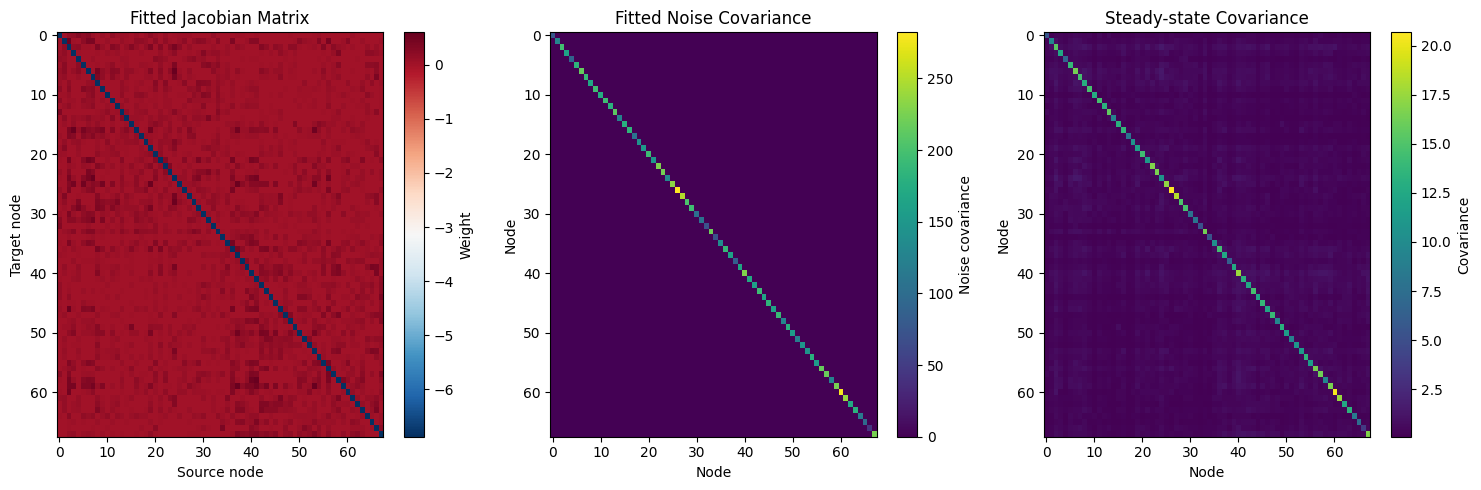

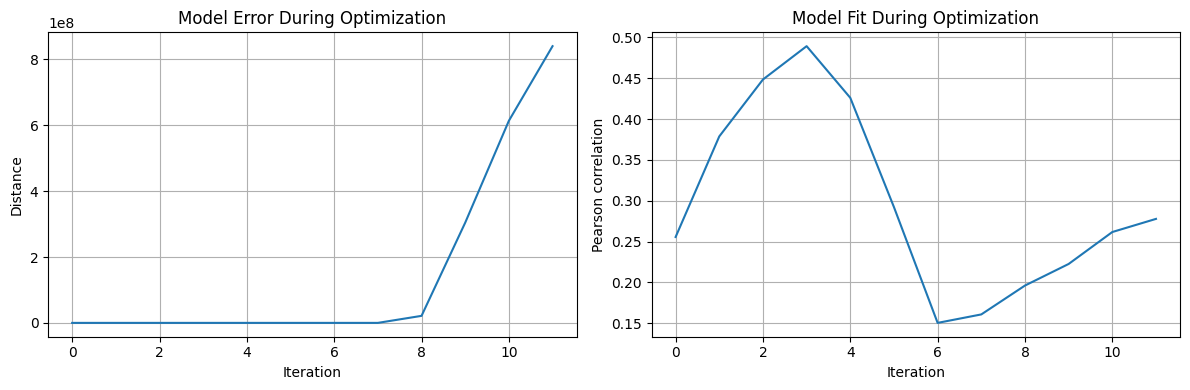

In [3]:
# Created on jan 2025
# https://journals.plos.org/ploscompbiol/article?id=10.1371/journal.pcbi.1012692

# numpy and scipy
import numpy as np
import scipy.stats as stt
import scipy.linalg as spl
import scipy.signal as spsg
import scipy.io as sio
from scipy.signal import welch, find_peaks

# MOU model
from test_MOU_largenet import MOUv2

# classification scikit-learn
import sklearn.linear_model as skllm
import sklearn.preprocessing as skppr
import sklearn.pipeline as skppl
import sklearn.neighbors as sklnn

# plotting
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sb
import pandas as pd

import tqdm


#### Set up data parameters

In [96]:
data_dir = './' # data repo
res_dir = './' # results
presentation_figs_dir = 'C:\\Users\\Bruna\\Documents\\Cogmaster\\M2\\Stage\\presentations\\3_4_26'
graph_format = 'png' # graph formatting

# data and model parameters
n_sub = 48
N = 68 # number of regions; size of network for AAL90

conds = ['CTR', 'SCZ']
n_cond = len(conds) # number of conditions

situation_idx = 0 # set to 1 if using data from the Reduced Wong-Wang model, 0 if using empirical data
situations = ['empirical', 'simulated']

In [97]:
# Load data simulated with Reduced Wong-Wang model
#RWW_data_path = "c:\\Users\\Bruna\\Documents\\Cogmaster\\M2\\Stage\\scripts\\TVBOptim\\results\\simulated_bold.npy"

if situation_idx == 1: # using simulated data
    RWW_data_path = r"C:\Users\Bruna\Documents\Cogmaster\M2\Stage\scripts\TVBOptim\results\learning_rate_0.0325_max_steps_300\bold_gd.npy"
    TS_RWW = np.load(RWW_data_path) # for the moment only have controls
    n_subjects_RWW = TS_RWW.shape[0]
    n_conditions_RWW = TS_RWW.shape[-1]
    print(f"Simulated data shape: {TS_RWW.shape}")
    # Separate into CTR and SCZ if using simulated data
    TS_CTR = TS_RWW[:,:,:,0] 
    TS_SCZ = TS_RWW[:,:,:,1] 
    # Load empirical data for comparing and as util for reshaping simulated data
    TS_CTR_emp  = np.load('TS_Control.npy')
    print(f"Empirical data shape: {TS_CTR_emp.shape}")
    # We want to reshape into (n_subjects, n_regions, n_timepoints, n_conditions)
    n_time_points = TS_CTR_emp.shape[-1]
    new_array = TS_RWW.reshape(n_subjects_RWW, N, n_time_points, n_conditions_RWW) 
    print(f"Reshaped simulated data shape: {TS_CTR.shape}")
else:
    TS_CTR = np.load('TS_Control.npy')
    TS_SCZ = np.load('TS_Schizo.npy')
    print(f"Empirical data shape: {TS_CTR.shape}")
    # Separate the participants by condition
    condition_0 = TS_CTR[0:n_sub, 0:N, :]  # all participants (condition 0)
    condition_1 = TS_SCZ[:, 0:N, :]  # Last 48 participants (condition 1)

    # Determine the maximum number of participants in either condition (for alignment)
    max_participants = max(condition_0.shape[2], condition_1.shape[2])

    # Pad the smaller group to match the size of the larger one along the participant dimension
    condition_0_padded = np.pad(condition_0, ((0, 0), (0, 0), (0, max_participants - condition_0.shape[2])), mode='constant')
    condition_1_padded = np.pad(condition_1, ((0, 0), (0, 0), (0, max_participants - condition_1.shape[2])), mode='constant')

    # Stack the conditions along the fourth dimension
    new_array = np.stack((condition_0_padded, condition_1_padded), axis=3)

    print("New array shape:", new_array.shape)

Empirical data shape: (116, 82, 152)
New array shape: (48, 68, 152, 2)


Text(0.5, 1.0, 'Filtered BOLD activity for participant 0 - Condition: CTR')

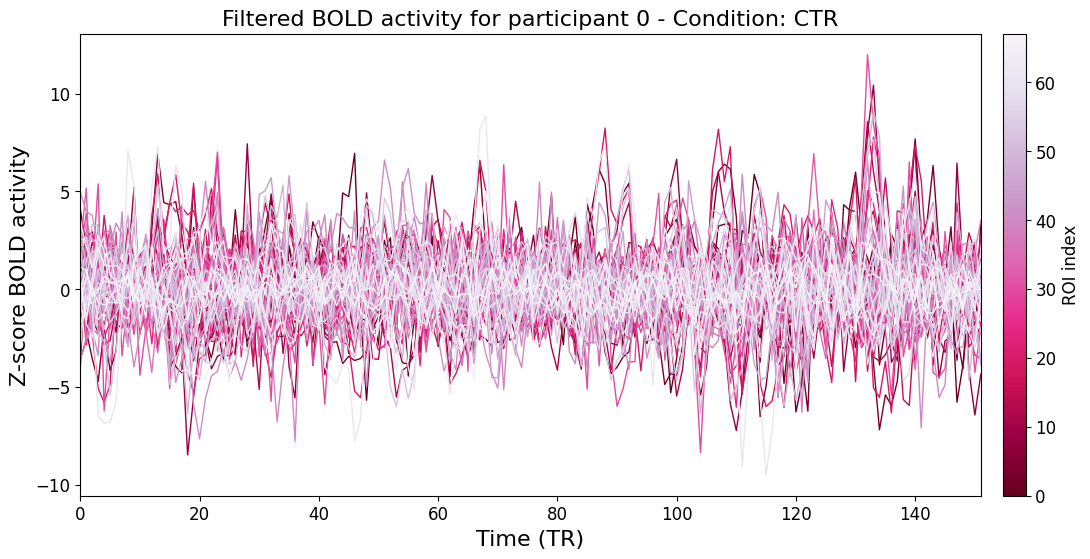

In [98]:
plot_participant = 0
plot_cond = 0 #scz for 1, ctr for 0

cmap = plt.cm.PuRd_r
n_nodes = N
norm = plt.Normalize(vmin=0, vmax=n_nodes - 1)

fig, ax = plt.subplots(figsize=(14,6))

for roi in range(n_nodes):
	ax.plot(
		range(new_array.shape[2]),
		new_array[plot_participant, roi, :, plot_cond], color=cmap(norm(roi)), lw=1)

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label('ROI index', fontsize=12)

ax.set_xlim(0, new_array.shape[2] - 1)
ax.set_xlabel('Time (TR)', fontsize=16)
ax.set_ylabel('Z-score BOLD activity', fontsize=16)
ax.set_title(f"Filtered BOLD activity for participant {plot_participant} - Condition: {conds[plot_cond]}", fontsize = 16)


In [99]:
def zscore_check(x, axis=None, thres= 1e-10, verbose=False):
    """Check if the input array is z-scored (mean ~ 0 and std ~ 1) along the specified axis."""
    mean = np.mean(x, axis=axis)
    std = np.std(x, axis=axis, ddof=0)  # ddof=0 matches most z-score implementations
    if verbose:
        print(f"mean ~ 0? max|mean|={np.max(np.abs(mean)):.3e}")
        print(f"std ~ 1? max|std-1|={np.max(np.abs(std-1)):.3e}")
    if np.max(np.abs(mean)) > thres or np.max(np.abs(std-1)) > thres:
        if verbose:
            print(
            f"Signal is not z-scored: mean is not close to 0 or std is not close to 1 "
            f"(max|mean|={np.max(np.abs(mean)):.3e}); max|std-1|={np.max(np.abs(std-1)):.3e})"
                )
        return False 
    
    else: 
        if verbose:
            print(f"Signal is z-scored: mean is close to 0 and std is close to 1 (max|mean|={np.max(np.abs(mean)):.3e}); max|std-1|={np.max(np.abs(std-1)):.3e})")
        return True
    
print("\nChecking if the data is z-scored...")
print(zscore_check(new_array, axis=2, verbose=True))


Checking if the data is z-scored...
mean ~ 0? max|mean|=2.300e-03
std ~ 1? max|std-1|=2.546e+01
Signal is not z-scored: mean is not close to 0 or std is not close to 1 (max|mean|=2.300e-03); max|std-1|=2.546e+01)
False


In [100]:
test_run = 1

if test_run:
    n_sub = 3

Valid ROI peaks: 68/68
Mean peak frequency: 0.0467 Hz
Median peak frequency: 0.0296 Hz


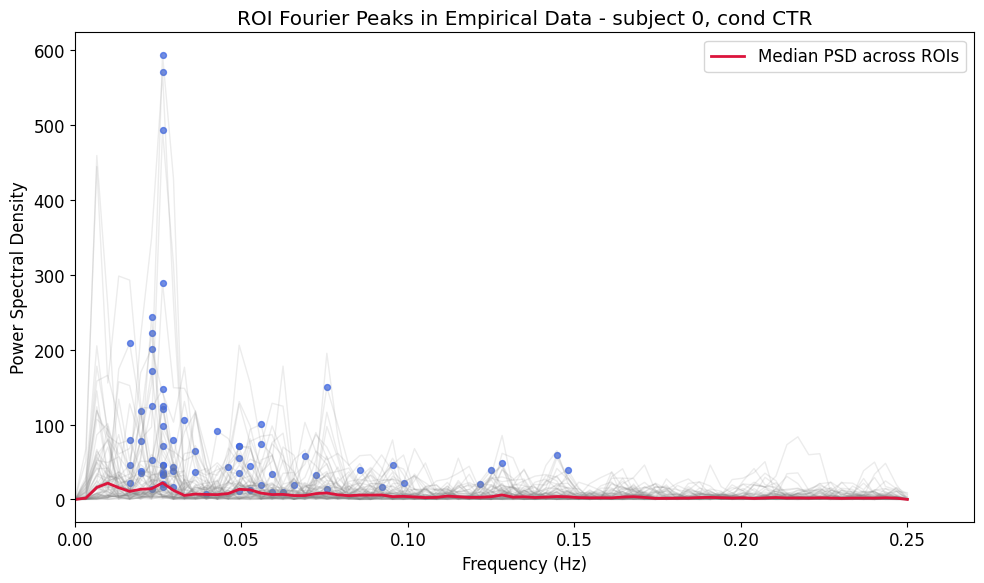

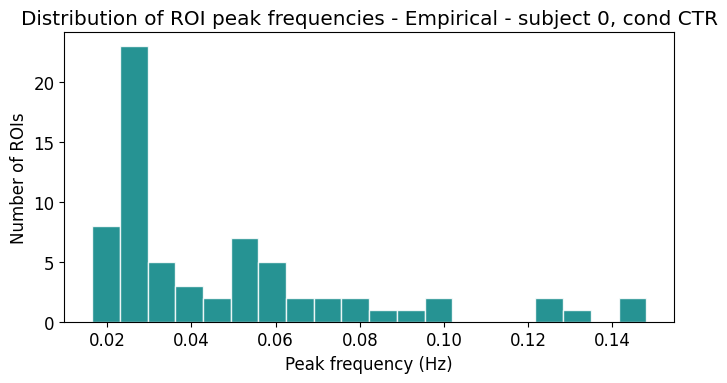

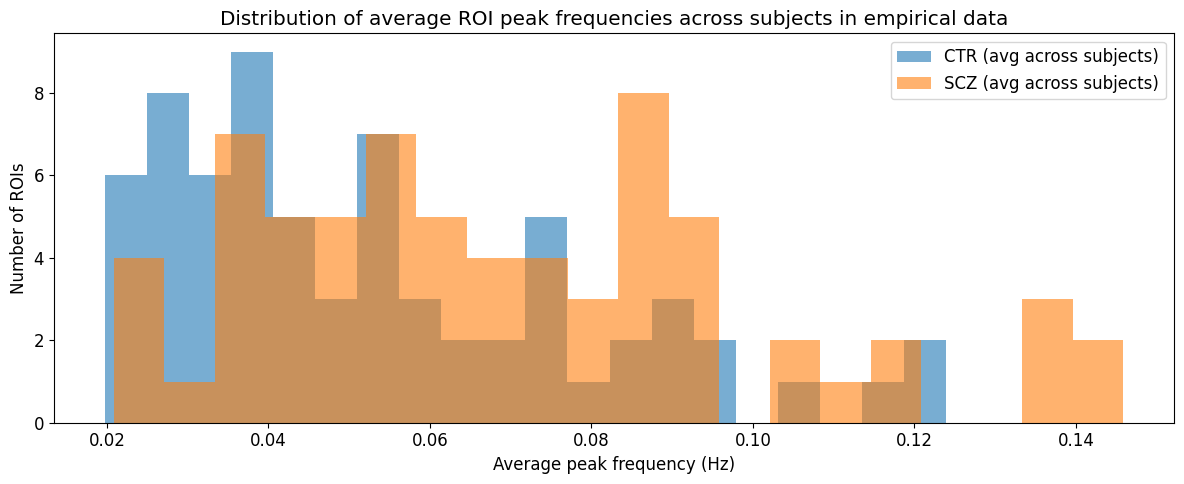

In [101]:
# Fourier peaks per ROI for one subject/condition
# -------- choose data --------
plot_participant = 0
plot_cond = 0  # 0=CTR, 1=SCZ in your setup
X = new_array[plot_participant, :, :, plot_cond]  # shape: [n_rois, n_timepoints]

# -------- compute PSD and dominant peaks --------
def compute_psd_and_peaks(X, TR = 2.0, fmin = 0.01, fmax = 0.25, verbose=True):
    """
    Compute power spectral density (PSD) for each ROI and identify the dominant
    frequency peak within a specified band.

    Parameters
    ----------
    X : ndarray of shape [n_rois, n_timepoints]
        Time series data for each ROI.
    TR : float
        BOLD repetition time in seconds.
    fmin : float
        Minimum frequency of interest in Hz.
    fmax : float
        Maximum frequency of interest in Hz.

    Returns
    -------
    peak_freqs : ndarray of shape [n_rois]
        Dominant frequency peak for each ROI (NaN if no valid peak found).
    peak_powers : ndarray of shape [n_rois]
        Power at the dominant frequency peak for each ROI (NaN if no valid peak found).
    psd_all : ndarray of shape [n_rois, n_freqs]
        Power spectral density for all ROIs across frequencies.
    freqs_ref : ndarray of shape [n_freqs]
        Frequency values corresponding to the PSD estimates.
    """
    fs = 1.0 / TR # sampling frequency in Hz
    n_rois = X.shape[0]
    peak_freqs = np.full(n_rois, np.nan)
    peak_powers = np.full(n_rois, np.nan)
    psd_all = []
    freqs_ref = None

    for r in range(n_rois):
        x = X[r]
        x = x - np.mean(x)  # remove DC
        
        freqs, psd = welch(x, fs=fs)

        if freqs_ref is None:
            freqs_ref = freqs
        psd_all.append(psd)

        band_mask = (freqs >= fmin) & (freqs <= fmax)
        f_band = freqs[band_mask]
        p_band = psd[band_mask]

        if len(p_band) < 3:
            continue

        # candidate local maxima
        pk_idx, _ = find_peaks(p_band)
        if len(pk_idx) == 0:
            # fallback: global max in band
            i_max = np.argmax(p_band)
            peak_freqs[r] = f_band[i_max]
            peak_powers[r] = p_band[i_max]
        else:
            # choose strongest local peak
            best_local = pk_idx[np.argmax(p_band[pk_idx])]
            peak_freqs[r] = f_band[best_local]
            peak_powers[r] = p_band[best_local]

    psd_all = np.array(psd_all)  # shape: [n_rois, n_freqs]
    valid = ~np.isnan(peak_freqs)
    
    if verbose:
        print(f"Valid ROI peaks: {valid.sum()}/{n_rois}")
    
        print(f"Mean peak frequency: {np.nanmean(peak_freqs):.4f} Hz")
        print(f"Median peak frequency: {np.nanmedian(peak_freqs):.4f} Hz")
    
    return peak_freqs, freqs_ref, psd_all


peak_freqs, freqs_ref, psd_all = compute_psd_and_peaks(X, TR=2.0, fmin=0.01, fmax=0.25, verbose=True)

valid = ~np.isnan(peak_freqs)

# Get peaks for all participants and conditions
peak_freqs_all = np.zeros((n_sub, N, n_cond))

for part_temp in range(n_sub):
    for cond_temp in range(n_cond):
        X_temp = new_array[part_temp, :, :, cond_temp]
        peak_freqs_temp,_ , _ = compute_psd_and_peaks(X_temp, TR=2.0, fmin=0.01, fmax=0.25, verbose=False)
        peak_freqs_all[part_temp, :, cond_temp] = peak_freqs_temp

# Sum over participants to get average peak frequency per ROI and condition
avg_peak_freqs = np.nanmean(peak_freqs_all, axis=0)

# -------- plot PSDs + peaks --------
plt.figure(figsize=(10, 6))
for r in range(N):
    plt.plot(freqs_ref, psd_all[r], color="gray", alpha=0.15, linewidth=1)

median_psd = np.median(psd_all, axis=0)
plt.plot(freqs_ref, median_psd, color="crimson", linewidth=2, label="Median PSD across ROIs")

# overlay detected peaks at ROI-specific frequencies (on their own PSD values)
for r in np.where(valid)[0]:
    # get power at closest frequency bin
    idx = np.argmin(np.abs(freqs_ref - peak_freqs[r]))
    plt.scatter(peak_freqs[r], psd_all[r, idx], s=18, color="royalblue", alpha=0.75)

plt.xlim(0, np.max(freqs_ref) + 0.02)
plt.xlabel("Frequency (Hz)")
plt.ylabel("Power Spectral Density")
plt.title(f"ROI Fourier Peaks in {situations[situation_idx].capitalize()} Data - subject {plot_participant}, cond {conds[plot_cond]}")
plt.legend()
plt.tight_layout()
fig_path = presentation_figs_dir + f"/PSD_peaks_{situations[situation_idx]}_sub{plot_participant}_cond{plot_cond}.{graph_format}"
plt.savefig(fig_path, format=graph_format, dpi=300)
plt.show()

# -------- histogram of peak frequencies for one participant & condition  --------
plt.figure(figsize=(7, 4))
plt.hist(peak_freqs[valid], bins=20, color="teal", alpha=0.85, edgecolor="white")
plt.xlabel("Peak frequency (Hz)")
plt.ylabel("Number of ROIs")
plt.title(f"Distribution of ROI peak frequencies - {situations[situation_idx].capitalize()} - subject {plot_participant}, cond {conds[plot_cond]}")
fig_path = presentation_figs_dir + f"/hist_peak_freqs_{situations[situation_idx]}_sub{plot_participant}_cond{plot_cond}.{graph_format}"
plt.savefig(fig_path, format=graph_format, dpi=300)
plt.tight_layout()
plt.show()

# -------- histogram of average peak frequencies across participants for each condition --------
plt.figure(figsize=(12, 5))
for cond_temp in range(n_cond):
    avg_peaks_cond = avg_peak_freqs[:, cond_temp]
    valid_cond = ~np.isnan(avg_peaks_cond)
    plt.hist(avg_peaks_cond[valid_cond], bins=20, alpha=0.6, label=f"{conds[cond_temp]} (avg across subjects)")
plt.xlabel("Average peak frequency (Hz)")
plt.ylabel("Number of ROIs")
plt.title(f"Distribution of average ROI peak frequencies across subjects in {situations[situation_idx].lower()} data")
fig_path = presentation_figs_dir + f"/hist_avg_peak_freqs_{situations[situation_idx]}.{graph_format}"
plt.savefig(fig_path, format=graph_format, dpi=300)
plt.tight_layout()
plt.legend()
# Optional: save for later analyses
# np.save(res_dir + f"peak_freqs_sub{plot_participant}_cond{plot_cond}.npy", peak_freqs)

In [93]:
n_sub

48

In [90]:
peak_freqs_all[2,:,0]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:
need_zscore = 0

if need_zscore:
    from utils import z_score_per_region
    z_scored_array = z_score_per_region(new_array)
    print("Data z-scored per region.")

#### Structural data and masks

In [70]:
# create topological mask for AAL90

SCR = sio.loadmat('SC_EnigmadK68.mat')['matrix']
SC=SCR/np.max(SCR)
lim_SC = 0.2 # limit DTI value to determine SC (only connections with larger values are tuned)
# anatomy-derived mask for existing connections for EC
mask_EC = np.zeros([N,N],dtype=bool) # EC weights to tune
mask_EC[SC>lim_SC] = True
for i in range(N):
    mask_EC[i,i] = False # no self connection
    mask_EC[i,N-1-i] = True # additional interhemispherical connections
print('network size:', N)
print('EC density:', mask_EC.sum()/float(N*(N-1)))

# diagonal mask for input noise matrix (so far, tune noise matrix for diagonal elements only)
mask_Sigma = np.eye(N,dtype=bool)
regul_Sigma = 0.0

network size: 68
EC density: 0.31562774363476737


### MOU fitting

In [46]:
# Set n_sub as the number of subjects in the RWW
if situation_idx == 1:
    n_sub = n_subjects_RWW
    n_cond = n_conditions_RWW

In [71]:
# Test: save number of iterations to see if algorithm converged
iter_mod = np.zeros([n_sub, n_cond], dtype=int)

  0%|          | 0/3 [00:00<?, ?it/s]

sub 0 ; cond 0 : {'n_tau': 2, 'iterations': 85, 'distance': np.float64(0.8093652850793382), 'correlation': np.float64(0.7229274313828576), 'distance history': array([0.91027644, 0.90788178, 0.90564399, ..., 0.        , 0.        ,
       0.        ]), 'correlation history': array([0.42523869, 0.43323628, 0.44097348, ..., 0.        , 0.        ,
       0.        ]), 'distFC0': np.float64(0.7696296423303469), 'distFC1': np.float64(0.8495813056796608)}


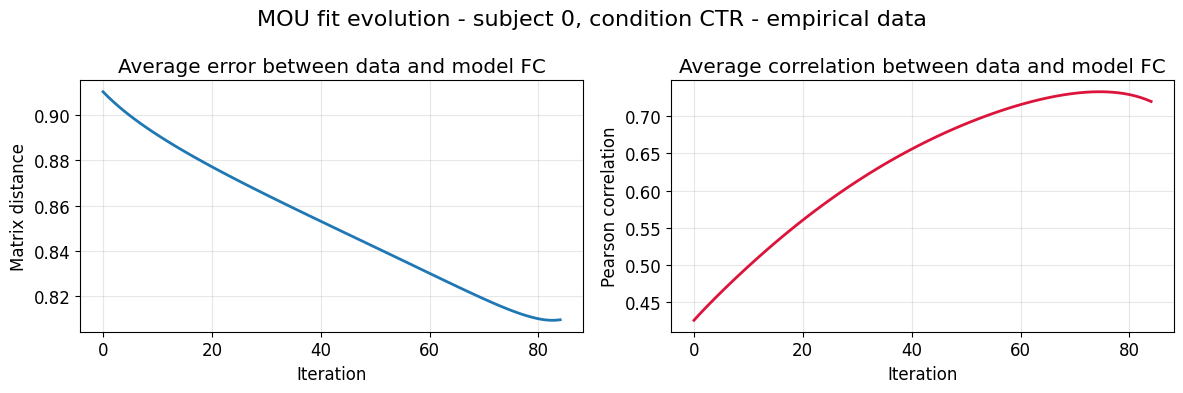

sub 0 ; cond 1 : {'n_tau': 2, 'iterations': 33, 'distance': np.float64(0.8259173583381227), 'correlation': np.float64(0.6381803646032902), 'distance history': array([0.89350402, 0.88902935, 0.8853842 , ..., 0.        , 0.        ,
       0.        ]), 'correlation history': array([0.40505704, 0.43514997, 0.46127201, ..., 0.        , 0.        ,
       0.        ]), 'distFC0': np.float64(0.717387956730482), 'distFC1': np.float64(0.9357465397417186)}


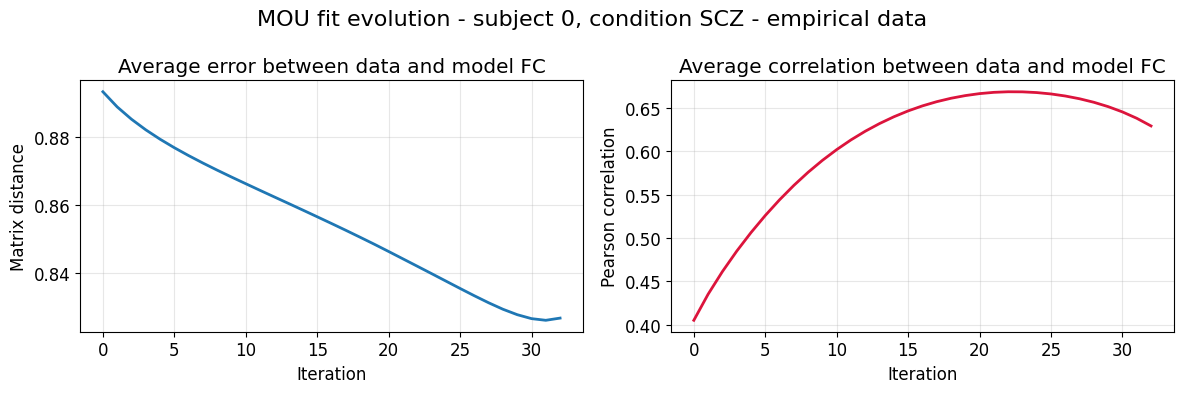

 33%|███▎      | 1/3 [00:03<00:06,  3.30s/it]

sub 1 ; cond 0 : {'n_tau': 2, 'iterations': 64, 'distance': np.float64(0.8398432189141269), 'correlation': np.float64(0.6386722276528989), 'distance history': array([0.90996101, 0.90808797, 0.90630309, ..., 0.        , 0.        ,
       0.        ]), 'correlation history': array([0.41065815, 0.41663128, 0.42245376, ..., 0.        , 0.        ,
       0.        ]), 'distFC0': np.float64(0.8042254088975701), 'distFC1': np.float64(0.8757305056126651)}


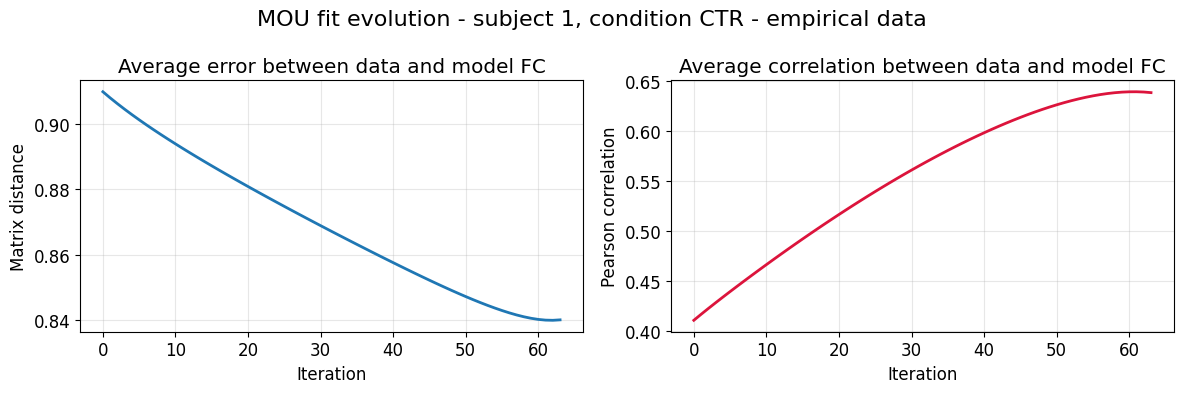

sub 1 ; cond 1 : {'n_tau': 2, 'iterations': 22, 'distance': np.float64(0.7672273158224381), 'correlation': np.float64(0.6069705595049253), 'distance history': array([0.86814839, 0.86264147, 0.85844158, ..., 0.        , 0.        ,
       0.        ]), 'correlation history': array([0.37659317, 0.41113801, 0.43989964, ..., 0.        , 0.        ,
       0.        ]), 'distFC0': np.float64(1.8279078307353436), 'distFC1': np.float64(119.62805303119944)}


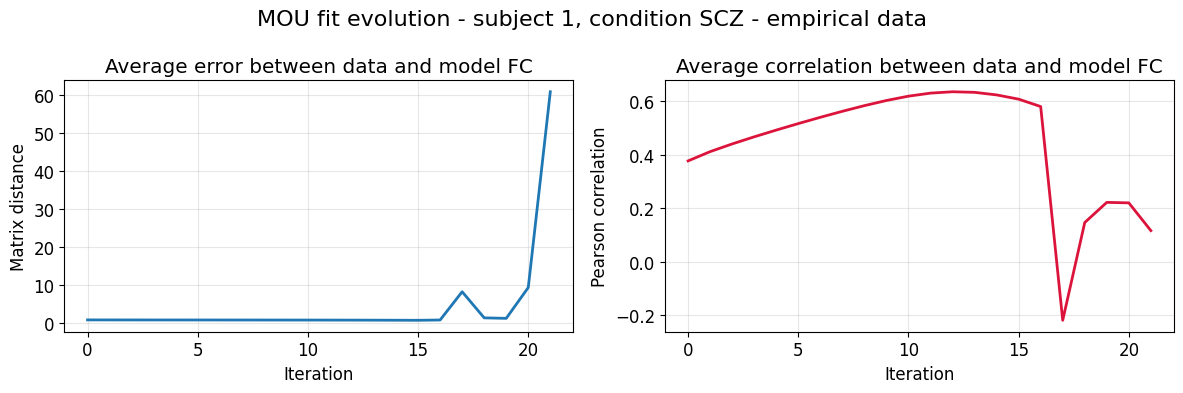

 67%|██████▋   | 2/3 [00:07<00:03,  3.61s/it]

sub 2 ; cond 0 : {'n_tau': 2, 'iterations': 53, 'distance': np.float64(0.752035983831851), 'correlation': np.float64(0.7473924266808853), 'distance history': array([0.92873811, 0.92343179, 0.91907834, ..., 0.        , 0.        ,
       0.        ]), 'correlation history': array([0.40366316, 0.43909035, 0.469706  , ..., 0.        , 0.        ,
       0.        ]), 'distFC0': np.float64(0.710801351094997), 'distFC1': np.float64(0.7966109801609786)}


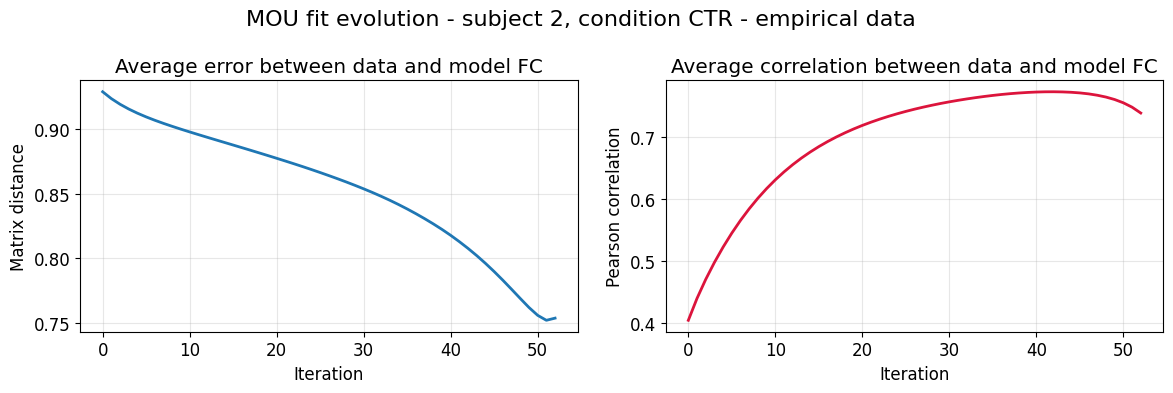

sub 2 ; cond 1 : {'n_tau': 2, 'iterations': 50, 'distance': np.float64(0.8253947112067905), 'correlation': np.float64(0.6507725235988846), 'distance history': array([0.89717284, 0.89452792, 0.89207711, ..., 0.        , 0.        ,
       0.        ]), 'correlation history': array([0.44431835, 0.45556489, 0.4662472 , ..., 0.        , 0.        ,
       0.        ]), 'distFC0': np.float64(0.7468348190493633), 'distFC1': np.float64(0.9046237092012703)}


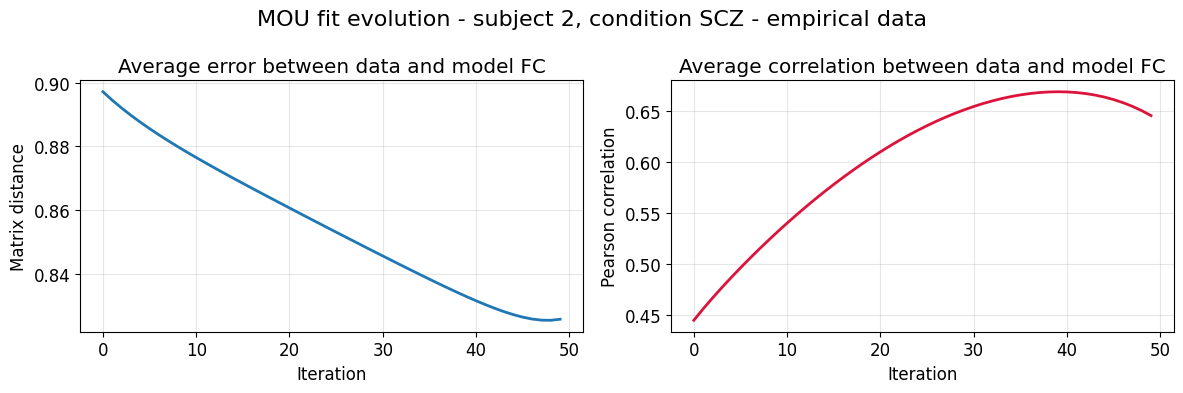

100%|██████████| 3/3 [00:10<00:00,  3.57s/it]

Mean iterations: 3.1979166666666665
Max iterations: 85
Mean distance FC0: 0.9294645014730171
Mean distance FC1: 20.66505767859929


In [73]:
min_val_EC = 0. # minimal value for EC
max_val_EC = 1. # maximal value for EC
min_val_Sigma = 0. # minimal value for Sigma

# arrays to store results
var_BOLD = np.zeros([n_sub,n_cond,N]) # empirical BOLD variance
J_mod = np.zeros([n_sub,n_cond,N,N]) # model Jacobian (EC.) In the article of Entropy production B=-J
Sigma_mod = np.zeros([n_sub,n_cond,N,N]) # model sigma. In the article of Entropy production sigma=2D
FC0_mod = np.zeros([n_sub,n_cond,N,N]) # model zero-lad FC
err_mod = np.zeros([n_sub,n_cond]) # model error
fit_mod = np.zeros([n_sub,n_cond]) # model goodness of fit (Pearson corr)

verbose=True

## TEST : change min_iter
min_iter = 20
## END TEST 

# Initialize average FC0 and FC1 distance
avg_dist_FC0 = 0.0
avg_dist_FC1 = 0.0

# loop over subject and conditions
for i_sub in tqdm.tqdm(range(n_sub)):
    for i_cond in range(n_cond):
        # get time series
        ts = new_array[i_sub,:,:,i_cond]
        # store empirical BOLD variance (48, 68, 152, 2)
        var_BOLD[i_sub,i_cond,:] = ts.var(axis=1)
        FC0 = np.corrcoef(new_array[i_sub,:,:,i_cond]) 
        FC1 = FC0/np.max(FC0)
        lim_FC = 0.1 # limit DTI value to determine SC (only connections with larger values are tuned)
        mask_EC = np.zeros([N,N],dtype=bool) # EC weights to tune
        mask_EC[FC1>lim_FC] = True
        for i in range(N):
            mask_EC[i,i] = False # no self connection
            mask_EC[i,N-1-i] = True # additional interhemispherical connections
 
        # invert model
        mou_est = MOUv2()
        mou_est.fit(ts.T, mask_C=mask_EC, mask_Sigma=mask_Sigma, algo_version='true', min_iter=min_iter, epsilon_C=0.005, epsilon_Sigma=0.005*n_nodes) #, verbose=True)

        # test : save nb of iterations
        iter_mod[i_sub, i_cond] = mou_est.d_fit["iterations"]

        # store results
        J_mod[i_sub,i_cond,:,:] = mou_est.J
        Sigma_mod[i_sub,i_cond,:,:] = mou_est.Sigma
        FC0_mod[i_sub,i_cond,:,:] = spl.solve_lyapunov(J_mod[i_sub,i_cond,:,:].T, -Sigma_mod[i_sub,i_cond,:,:])
        err_mod[i_sub,i_cond] = mou_est.d_fit['distance']
        fit_mod[i_sub,i_cond] = mou_est.d_fit['correlation']
        
        # Update average distances for FC0 and FC1
        avg_dist_FC0 += mou_est.d_fit['distFC0']
        avg_dist_FC1 += mou_est.d_fit['distFC1']

        if verbose:
            print('sub', i_sub, '; cond', i_cond, ':', mou_est.d_fit)
            
            d = mou_est.d_fit
            n_it = int(d["iterations"])

            # Error btw model and data for FC0 and FC1 (matrix distance) -> = 0.5 * (dist_Q0 + dist_Qtau)
            dist_hist = np.asarray(d["distance history"][:n_it])
            # Corr between model and empirical data for FC0 and FC1 -> =  0.5 * (Pearson_Q0  + Pearson_Qtau)
            corr_hist = np.asarray(d["correlation history"][:n_it])

            fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    
            ax[0].plot(dist_hist, lw=2)
            ax[0].set_title("Average error between data and model FC")
            ax[0].set_xlabel("Iteration")
            ax[0].set_ylabel("Matrix distance")
            ax[0].grid(alpha=0.3)

            ax[1].plot(corr_hist, lw=2, color="crimson")
            ax[1].set_title("Average correlation between data and model FC")
            
            ax[1].set_xlabel("Iteration")
            ax[1].set_ylabel("Pearson correlation")
            ax[1].grid(alpha=0.3)

            plt.suptitle(f"MOU fit evolution - subject {i_sub}, condition {conds[i_cond]} - {situations[situation_idx]} data", fontsize=16)
            plt.tight_layout()
            # Save figure
            plt.savefig(presentation_figs_dir + f"/MOU_fit_evolution_{situations[situation_idx]}_sub{i_sub}_cond{conds[i_cond]}.{graph_format}", format=graph_format, dpi=300)
            plt.show()
            plt.close()
            
print("Mean iterations:", iter_mod.mean())
print("Max iterations:", iter_mod.max())
print("Mean distance FC0:", avg_dist_FC0 / (n_sub * n_cond))
print("Mean distance FC1:", avg_dist_FC1 / (n_sub * n_cond))

#### Test goodness of fit

C:\Users\Bruna\AppData\Local\Temp\ipykernel_38808\2502066870.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.violinplot(data=err_mod_df, x='cond', y='sum EC', palette=cols, alpha = 0.9)
C:\Users\Bruna\AppData\Local\Temp\ipykernel_38808\2502066870.py:18: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sb.violinplot(data=err_mod_df, x='cond', y='sum EC', palette=cols, alpha = 0.9)
C:\Users\Bruna\AppData\Local\Temp\ipykernel_38808\2502066870.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.violinplot(data=fit_mod_df, x='cond', y='sum EC', palette=cols, alpha = 0.9)
C:\Users\Bruna\AppData\Local\Temp\ipykernel_38808\2502066870.py:45: UserWarning: The palet

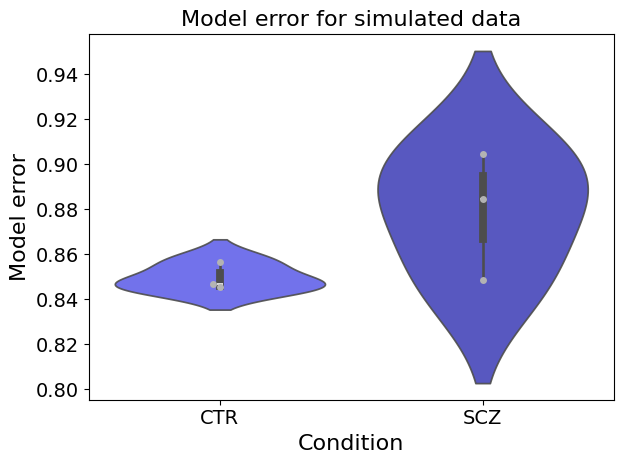

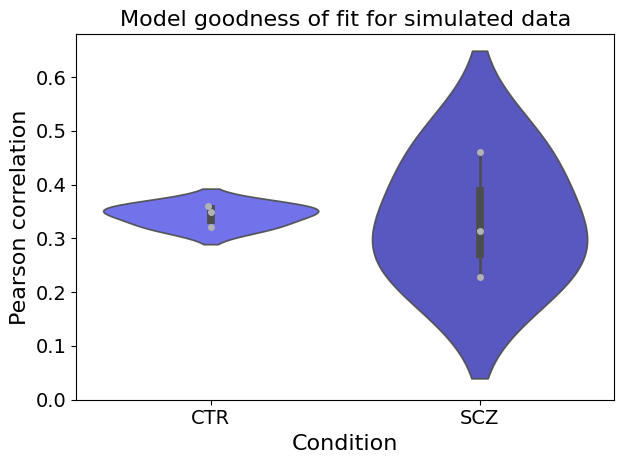

In [49]:
import os


mask_diag = np.eye(N, dtype=bool) # mask for diagonal elements

cols = [[0.3,0.3,1],[0.2,0.2,0.8],[0.1,0.1,0.6],[0,0,0.4]] # colors

# Model error computation
err_mod_tmp = dict()
err_mod_tmp['sum EC'] = err_mod.flatten()
err_mod_tmp['sub'] = np.repeat(np.arange(n_sub), n_cond).flatten()
err_mod_tmp['cond'] = np.repeat(np.array(conds, dtype=str).reshape([-1,n_cond]), n_sub, axis=0).flatten()

err_mod_df = pd.DataFrame(err_mod_tmp)

# Model error plot
plt.figure()
sb.violinplot(data=err_mod_df, x='cond', y='sum EC', palette=cols, alpha = 0.9)
sb.swarmplot(data=err_mod_df, x='cond', y='sum EC', color=[0.7,0.7,0.7])
#plt.axis(ymin=0, ymax=0.8)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title(f'Model error for {situations[situation_idx]} data', fontsize=16)
plt.xlabel('Condition',fontsize=16)
plt.ylabel('Model error',fontsize=16)

plt.tight_layout()
# Save figure
fig_path = os.path.join(presentation_figs_dir, f'MOU_model_error_{situations[situation_idx]}.{graph_format}')
#plt.savefig(res_dir+'model_fit_error.eps', format='eps')
plt.savefig(fig_path, dpi=300)


# Pearson correlation
fit_mod_tmp = dict()
fit_mod_tmp['sum EC'] = fit_mod.flatten()
fit_mod_tmp['sub'] = np.repeat(np.arange(n_sub), n_cond).flatten()
fit_mod_tmp['cond'] = np.repeat(np.array(conds, dtype=str).reshape([-1,n_cond]), n_sub, axis=0).flatten()

fit_mod_df = pd.DataFrame(fit_mod_tmp)

# Correlation violin plot
plt.figure()
sb.violinplot(data=fit_mod_df, x='cond', y='sum EC', palette=cols, alpha = 0.9)
sb.swarmplot(data=fit_mod_df, x='cond', y='sum EC', color=[0.7,0.7,0.7])
plt.axis(ymin=0)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.title(f'Model goodness of fit for {situations[situation_idx]} data',fontsize=16)
plt.xlabel('Condition',fontsize=16)
plt.ylabel('Pearson correlation',fontsize=16)
plt.tight_layout()

# Save figure
fig_path = os.path.join(presentation_figs_dir, f'MOU_model_goodness_fit_{situations[situation_idx]}.{graph_format}')
plt.savefig(fig_path, dpi=300)


# Example EC

# plt.figure(figsize=(5,4))
# plt.imshow(np.maximum(J_mod[0,0,:,:],0), cmap='Reds')   # Show only the non-negatives
# #plt.imshow(J_mod[0,0,:,:], cmap='Reds')   # Show only the non-negatives
# plt.colorbar()
# plt.xticks(fontsize=14)
# plt.yticks(fontsize=14)
# plt.xlabel('Target ROI index', fontsize=16)
# plt.ylabel('Source ROI index', fontsize=16)
# plt.tight_layout()
# plt.savefig(res_dir+'example_EC.eps', format='eps')

# # Example EC

# plt.figure(figsize=(5,4))
# #plt.imshow(np.maximum(Sigma_mod[0,0,:,:],0), cmap='Reds')   # Show only the non-negatives
# plt.imshow(Sigma_mod[0,0,:,:], cmap='Reds')   # Show only the non-negatives
# plt.colorbar()
# plt.xticks(fontsize=14)
# plt.yticks(fontsize=14)
# plt.xlabel('Target ROI index', fontsize=16)
# plt.ylabel('Source ROI index', fontsize=16)
# plt.tight_layout()
# plt.savefig(res_dir+'example_EC.eps', format='eps')

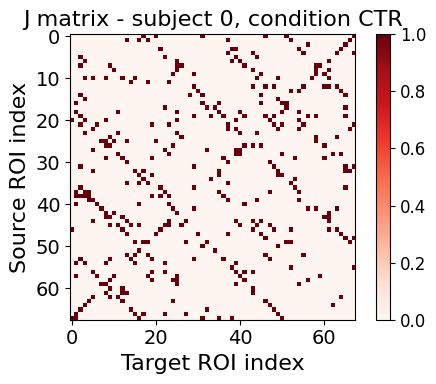

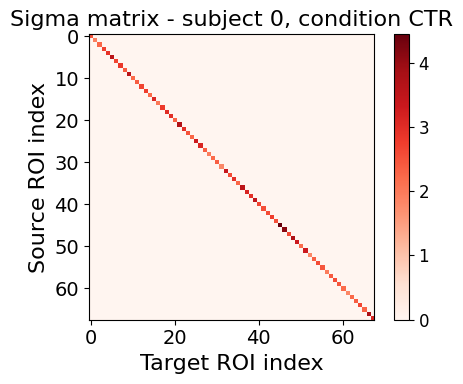

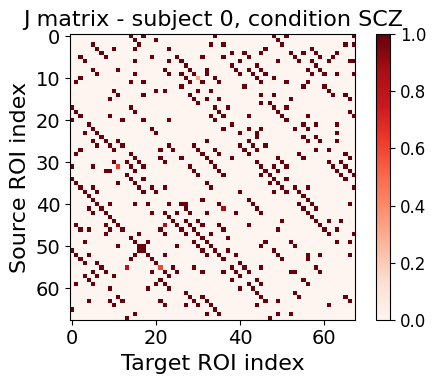

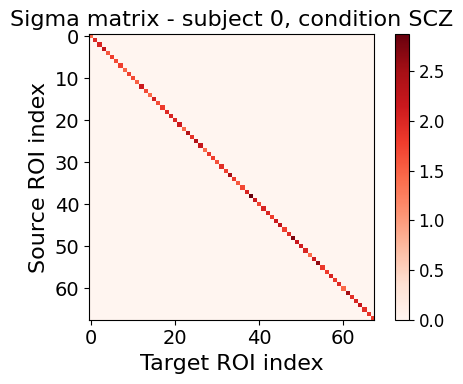

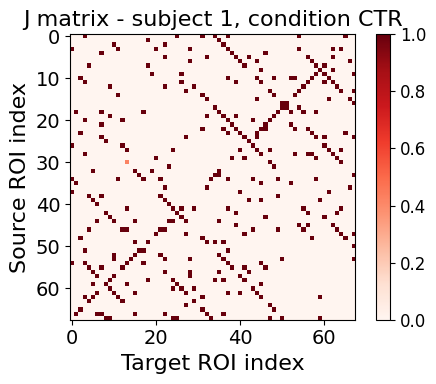

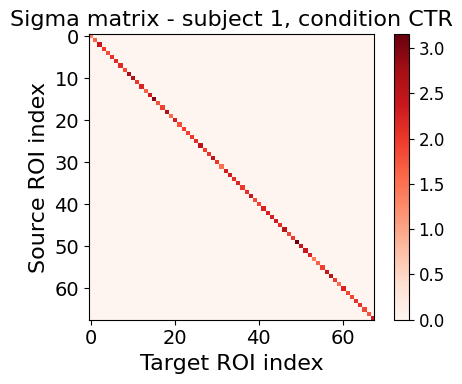

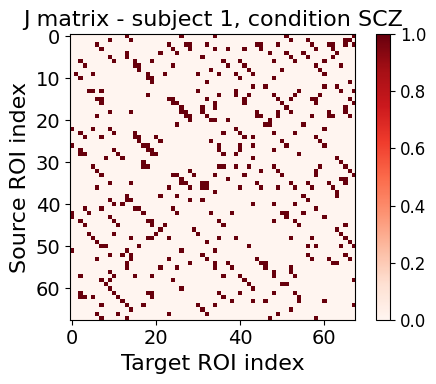

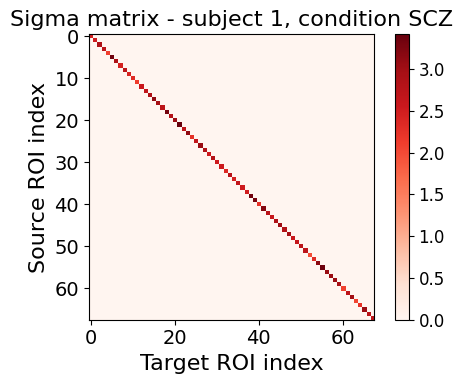

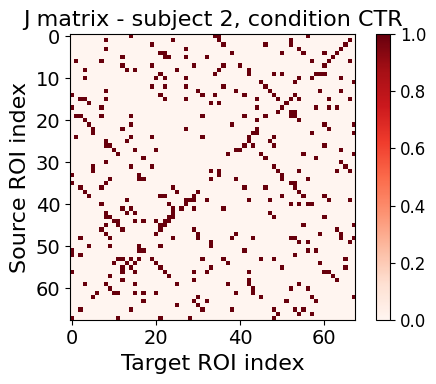

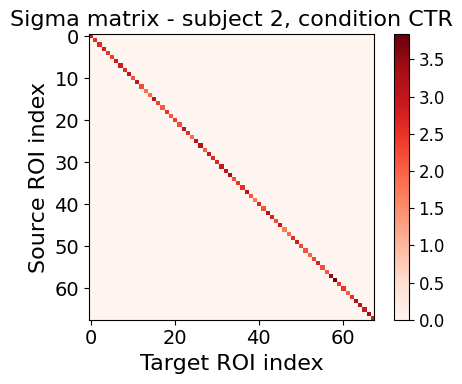

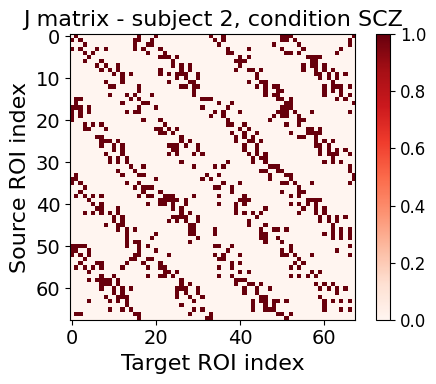

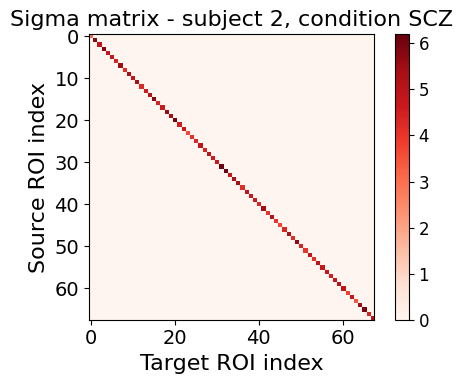

In [50]:
for i_sub in range(n_sub):
    for i_cond in range(n_cond):
        J = J_mod[i_sub, i_cond, :, :]
        Sigma = Sigma_mod[i_sub, i_cond, :, :]
        FC0 = FC0_mod[i_sub, i_cond, :, :]

        # Plotting the jacobian for one subject and conditon
        plt.figure(figsize=(5,4))
        plt.imshow(np.maximum(J_mod[i_sub,i_cond,:,:],0), cmap='Reds')   # Show only the non-negatives
        #plt.imshow(J_mod[0,0,:,:], cmap='Reds')   # Show only the non-negatives
        plt.colorbar()
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        plt.title(f"J matrix - subject {i_sub}, condition {conds[i_cond]}", fontsize=16)
        plt.xlabel('Target ROI index', fontsize=16)
        plt.ylabel('Source ROI index', fontsize=16)
        plt.tight_layout()
        #plt.savefig(res_dir+'example_EC.eps', format='eps')
        # Save figure
        fig_path = os.path.join(presentation_figs_dir, f'MOU_J_{situations[situation_idx]}_sub{i_sub}_cond{conds[i_cond]}.{graph_format}')
        plt.savefig(fig_path, dpi=300)

        ## Plotting sigma for one subject and condition
        plt.figure(figsize=(5,4))
        #plt.imshow(np.maximum(Sigma_mod[0,0,:,:],0), cmap='Reds')   # Show only the non-negatives
        plt.imshow(Sigma_mod[i_sub,i_cond,:,:], cmap='Reds')   # Show only the non-negatives
        plt.colorbar()
        plt.xticks(fontsize=14)
        plt.yticks(fontsize=14)
        plt.title(f"Sigma matrix - subject {i_sub}, condition {conds[i_cond]}", fontsize=16)
        plt.xlabel('Target ROI index', fontsize=16)
        plt.ylabel('Source ROI index', fontsize=16)
        plt.tight_layout()
        # Save figure
        fig_path = os.path.join(presentation_figs_dir, f'MOU_Sigma_{situations[situation_idx]}_sub{i_sub}_cond{conds[i_cond]}.{graph_format}')
        plt.savefig(fig_path, dpi=300)

#### Entropy production rate calculation

In [51]:
# transpose to Saclay's framework
EPR = np.zeros([n_sub,n_cond])
Q_indiv = np.zeros([n_sub,n_cond,N,N])

for i_sub in range(n_sub):
    for i_cond in range(n_cond):

        try:
            B = np.copy(-J_mod[i_sub,i_cond,:,:].T) # B=-J
            D = np.copy(0.5 * Sigma_mod[i_sub,i_cond,:,:]) # D=1/2 * Sigma
            S = np.copy(FC0_mod[i_sub,i_cond,:,:])
            
            Q = np.dot(B, S) - D
            Q_indiv[i_sub,i_cond,:,:] = Q
            
            # sanity check
            if True:
                print('should be close to zero:', np.abs(np.dot(B,S) + np.dot(S,B.T) -2*D).max())
            
            # formula from Godreche Luck
            Dinv = np.linalg.pinv(D)
            Sinv = np.linalg.pinv(S)
            
            entropy_prod_rate = -np.trace(np.dot(np.dot(np.dot(Sinv, Q), Dinv), Q))  #-tr(S^(-1)*Q*D^(-1)*Q)
            EPR[i_sub,i_cond] = entropy_prod_rate

        except:
            print('problem with subject/cond:', i_sub, i_cond)
       

#np.save(res_dir+'EPR.npy',EPR)



should be close to zero: 9.325873406851315e-15
should be close to zero: 6.8833827526759706e-15
should be close to zero: 1.021405182655144e-14
should be close to zero: 1.021405182655144e-14
should be close to zero: 8.881784197001252e-15
should be close to zero: 2.042810365310288e-14


C:\Users\Bruna\AppData\Local\Temp\ipykernel_38808\2813494162.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sb.violinplot(data=EPR_df, x='sleep stage', y='EPR', palette=cols)
C:\Users\Bruna\AppData\Local\Temp\ipykernel_38808\2813494162.py:22: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  ax = sb.violinplot(data=EPR_df, x='sleep stage', y='EPR', palette=cols)


Text(43.472222222222214, 0.5, 'Entropy production rate')

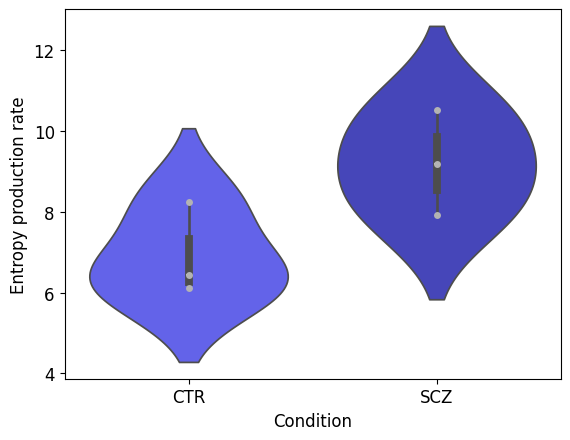

In [52]:
#%% plots

matplotlib.rc('font', size=12) 
matplotlib.rc('xtick', labelsize=12)
matplotlib.rc('ytick', labelsize=12)

cols = [[0.3,0.3,1],[0.2,0.2,0.8],[0.1,0.1,0.6],[0,0,0.4]]
cols2 = [[0.7,0.7,1],[0.6,0.6,1],[0.5,0.5,1],[0.4,0.4,1]]

EPR_tmp = dict()
EPR_tmp['sleep stage'] = np.repeat(np.array(conds, dtype=str).reshape([-1,n_cond]), n_sub, axis=0).flatten()
EPR_tmp['EPR'] = EPR.flatten()

EPR_df = pd.DataFrame(EPR_tmp)

#EPR_df=EPR_df.drop(index=13)


# real data

plt.figure()
ax = sb.violinplot(data=EPR_df, x='sleep stage', y='EPR', palette=cols)
sb.swarmplot(data=EPR_df, x='sleep stage', y='EPR', color=[0.7,0.7,0.7])
#plt.axis(ymin=-1.2, ymax=10)

plt.xlabel('Condition', fontsize=12)
plt.ylabel('Entropy production rate', fontsize=12)

#plt.savefig(res_dir+'entropy_prod_rate.eps', format='eps')

C:\Users\Bruna\AppData\Local\Temp\ipykernel_38808\849540568.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data,


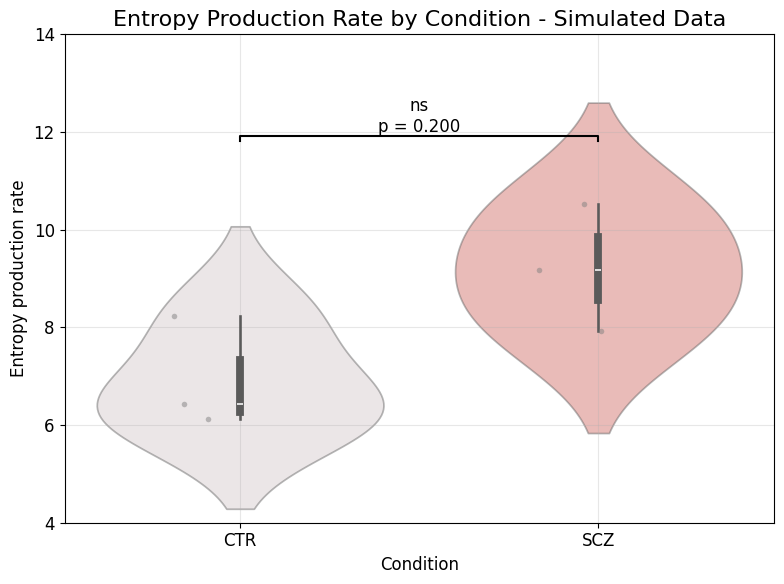


Statistical Test Results:
Mann-Whitney U test statistic: 1.00
p-value: 0.200


In [56]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

# Create sample data (replace with your actual data)
data = pd.DataFrame({
    'Condition': ['CTR']*n_sub + ['SCZ']*n_sub,
    'Entropy_production_rate': np.concatenate([
        EPR_df[EPR_df['sleep stage'] == 'CTR']['EPR'].tolist(),
        EPR_df[EPR_df['sleep stage'] == 'SCZ']['EPR'].tolist()
    ])
})

# Perform statistical test
ctr_data = data[data['Condition'] == 'CTR']['Entropy_production_rate']
scz_data = data[data['Condition'] == 'SCZ']['Entropy_production_rate']

# Perform Mann-Whitney U test (non-parametric test for independent samples)
statistic, p_value = stats.mannwhitneyu(ctr_data, scz_data, alternative='two-sided')

# Colors 
palette = {'CTR': '#D4C6C9', 'SCZ': '#E1544C'}

# Create the figure
plt.figure(figsize=(8, 6))

# Create violin plot
sns.violinplot(data=data, 
               x='Condition', 
               y='Entropy_production_rate',
               palette = palette,
               alpha=0.44)

# Add strip plot (individual points)
sns.stripplot(data=data,
             x='Condition',
             y='Entropy_production_rate',
             color='gray',
             alpha=0.5,
             jitter=0.2,
             size=4)

# Add significance bar
def add_stat_annotation(p_value):
    # Define the significance level markers
    if p_value < 0.001:
        star_string = '***'
    elif p_value < 0.01:
        star_string = '**'
    elif p_value < 0.05:
        star_string = '*'
    else:
        star_string = 'ns'
    
    # Get y coordinates for the bar
    y_max = data['Entropy_production_rate'].max()
    bar_height = y_max + 1.3
    
    # Plot the significance bar
    x1, x2 = 0, 1  # x-coordinates for CTR and SCZ
    bar_height_diff = 0.1
    
    plt.plot([x1, x1, x2, x2], 
            [bar_height, bar_height + bar_height_diff, bar_height + bar_height_diff, bar_height],
            'k-', linewidth=1.5)
    
    # Add star annotation
    plt.text((x1 + x2) * 0.5, bar_height + bar_height_diff,
            f'{star_string}\np = {p_value:.3f}',
            ha='center', va='bottom')

# Add the significance annotation
add_stat_annotation(p_value)

# Customize the plot
plt.title(f'Entropy Production Rate by Condition - {situations[situation_idx].capitalize()} Data', fontsize=16)
plt.xlabel('Condition')
plt.ylabel('Entropy production rate')
plt.ylim(4, 14)  # Adjust the upper limit if needed to show the significance bar
plt.grid(True, alpha=0.3)

# Adjust layout
plt.tight_layout()

#plt.savefig(res_dir+'entropy_prod_rate_statbar.png', format='png', dpi=300)
fig_path = os.path.join(presentation_figs_dir, f'entropy_prod_rate_statbar_{situations[situation_idx]}.{graph_format}')
plt.savefig(fig_path, dpi=300)
plt.show()
plt.close()

# Print statistical test results
print(f'\nStatistical Test Results:')
print(f'Mann-Whitney U test statistic: {statistic:.2f}')
print(f'p-value: {p_value:.3f}')

### Grid search for better hyperparameters for MOU fitting

In [19]:
# Parameter sweep for MOUv2.fit (Lyapunov)
# Goal: improve distance, correlation, and especially distFC1.
from itertools import product
import numpy as np
import pandas as pd
import tqdm

# 1) Define which subject/condition pairs to use for tuning (keep small for speed)
max_sub_for_sweep = min(n_sub, 2)  # increase to n_sub for full sweep
eval_pairs = [(i_sub, i_cond) for i_sub in range(max_sub_for_sweep) for i_cond in range(n_cond)]
print("Sweep will evaluate pairs:", eval_pairs)

# 2) Hyperparameter grid
grid = {
    "algo_version": ["NeNe2020", "PCB2016"],
    "epsilon_C": [5e-4, 1e-3, 2e-3],
    "epsilon_Sigma": [5e-3, 1e-2, 2e-2],
    "regul_C": [0.0, 0.05, 0.1],
    "regul_Sigma": [0.0, 1e-3],
    "min_iter": [30, 50, 100],
    "max_iter": [2000],     # keep fixed for fair comparison
    "lim_FC": [0.05, 0.1],  # threshold used to build mask_EC from FC
}

keys = list(grid.keys())
values = [grid[k] for k in keys]
n_combos = int(np.prod([len(v) for v in values]))
print("Total parameter combinations:", n_combos)

records = []

for combo in tqdm.tqdm(product(*values), total=n_combos):
    params = dict(zip(keys, combo))

    dist_list = []
    corr_list = []
    distFC0_list = []
    distFC1_list = []
    iter_list = []
    fail_count = 0

    for i_sub, i_cond in eval_pairs:
        ts = new_array[i_sub, :, :, i_cond]  # shape: nodes x time

        # Rebuild EC mask exactly as in your main loop, but with sweepable lim_FC
        FC0 = np.corrcoef(ts)
        FC1 = FC0 / np.max(np.abs(FC0))
        mask_EC_local = np.zeros((N, N), dtype=bool)
        mask_EC_local[FC1 > params["lim_FC"]] = True
        for i in range(N):
            mask_EC_local[i, i] = False
            mask_EC_local[i, N - 1 - i] = True

        mou_est = MOUv2()
        try:
            mou_est.fit(
                ts.T,
                mask_C=mask_EC_local,
                mask_Sigma=mask_Sigma,
                algo_version=params["algo_version"],
                min_iter=params["min_iter"],
                max_iter=params["max_iter"],
                epsilon_C=params["epsilon_C"],
                epsilon_Sigma=params["epsilon_Sigma"],
                regul_C=params["regul_C"],
                regul_Sigma=params["regul_Sigma"],
                verbose=False,
            )
            d = mou_est.d_fit
            dist_list.append(float(d["distance"]))
            corr_list.append(float(d["correlation"]))
            distFC0_list.append(float(d.get("distFC0", np.nan)))
            distFC1_list.append(float(d.get("distFC1", np.nan)))
            iter_list.append(int(d["iterations"]))
        except Exception:
            fail_count += 1

    n_ok = len(dist_list)
    if n_ok == 0:
        continue

    records.append({
        "algo_version": params["algo_version"],
        "epsilon_C": params["epsilon_C"],
        "epsilon_Sigma": params["epsilon_Sigma"],
        "regul_C": params["regul_C"],
        "regul_Sigma": params["regul_Sigma"],
        "min_iter": params["min_iter"],
        "max_iter": params["max_iter"],
        "lim_FC": params["lim_FC"],
        "n_ok": n_ok,
        "n_fail": fail_count,
        "mean_distance": np.mean(dist_list),
        "std_distance": np.std(dist_list),
        "mean_corr": np.mean(corr_list),
        "std_corr": np.std(corr_list),
        "mean_distFC0": np.nanmean(distFC0_list),
        "mean_distFC1": np.nanmean(distFC1_list),
        "mean_iter": np.mean(iter_list),
        "max_iter_used": np.max(iter_list),
    })

results = pd.DataFrame(records)

# Ranking rule: prioritize lower distance and lower distFC1, then higher correlation
results = results.sort_values(
    by=["mean_distance", "mean_distFC1", "mean_corr"],
    ascending=[True, True, False]
).reset_index(drop=True)

print("\nTop 10 parameter sets:")
display(results.head(10))

best = results.iloc[0]
best_fit_kwargs = {
    "algo_version": best["algo_version"],
    "epsilon_C": float(best["epsilon_C"]),
    "epsilon_Sigma": float(best["epsilon_Sigma"]),
    "regul_C": float(best["regul_C"]),
    "regul_Sigma": float(best["regul_Sigma"]),
    "min_iter": int(best["min_iter"]),
    "max_iter": int(best["max_iter"]),
}
best_lim_FC = float(best["lim_FC"])

print("\nBest fit kwargs for your main loop:")
print(best_fit_kwargs)
print("Best lim_FC:", best_lim_FC)

Sweep will evaluate pairs: [(0, 0), (0, 1), (1, 0), (1, 1)]
Total parameter combinations: 648


  0%|          | 0/648 [00:03<?, ?it/s]


KeyboardInterrupt: 

In [ ]:
# Refit full dataset with best grid-search parameters
import numpy as np
import pandas as pd
import scipy.linalg as spl
import tqdm

best = results.iloc[0]
best_fit_kwargs = {
    "algo_version": best["algo_version"],
    "epsilon_C": float(best["epsilon_C"]),
    "epsilon_Sigma": float(best["epsilon_Sigma"]),
    "regul_C": float(best["regul_C"]),
    "regul_Sigma": float(best["regul_Sigma"]),
    "min_iter": int(best["min_iter"]),
    "max_iter": int(best["max_iter"]),
}
best_lim_FC = float(best["lim_FC"])

print("Best parameters:")
print(best_fit_kwargs)
print("best_lim_FC:", best_lim_FC)

# Keep current results as baseline if they exist
err_mod_baseline = None
fit_mod_baseline = None
iter_mod_baseline = None

# New arrays for best run
var_BOLD_best = np.zeros((n_sub, n_cond, N))
J_mod_best = np.zeros((n_sub, n_cond, N, N))
Sigma_mod_best = np.zeros((n_sub, n_cond, N, N))
FC0_mod_best = np.zeros((n_sub, n_cond, N, N))
err_mod_best = np.zeros((n_sub, n_cond))
fit_mod_best = np.zeros((n_sub, n_cond))
iter_mod_best = np.zeros((n_sub, n_cond), dtype=int)
distFC0_best = np.zeros((n_sub, n_cond))
distFC1_best = np.zeros((n_sub, n_cond))

for i_sub in tqdm.tqdm(range(n_sub), desc="Refit with best params"):
    for i_cond in range(n_cond):
        ts = new_array[i_sub, :, :, i_cond]
        var_BOLD_best[i_sub, i_cond, :] = ts.var(axis=1)

        FC0 = np.corrcoef(ts)
        FC1 = FC0 / np.max(np.abs(FC0))
        mask_EC_local = np.zeros((N, N), dtype=bool)
        mask_EC_local[FC1 > best_lim_FC] = True
        for i in range(N):
            mask_EC_local[i, i] = False
            mask_EC_local[i, N - 1 - i] = True

        mou_est = MOUv2()
        mou_est.fit(
            ts.T,
            mask_C=mask_EC_local,
            mask_Sigma=mask_Sigma,
            verbose=False,
            **best_fit_kwargs
        )

        d = mou_est.d_fit
        J_mod_best[i_sub, i_cond, :, :] = mou_est.J
        Sigma_mod_best[i_sub, i_cond, :, :] = mou_est.Sigma
        FC0_mod_best[i_sub, i_cond, :, :] = spl.solve_lyapunov(
            J_mod_best[i_sub, i_cond, :, :].T, -Sigma_mod_best[i_sub, i_cond, :, :]
        )
        err_mod_best[i_sub, i_cond] = float(d["distance"])
        fit_mod_best[i_sub, i_cond] = float(d["correlation"])
        iter_mod_best[i_sub, i_cond] = int(d["iterations"])
        distFC0_best[i_sub, i_cond] = float(d.get("distFC0", np.nan))
        distFC1_best[i_sub, i_cond] = float(d.get("distFC1", np.nan))

# Quick summary
summary_rows = []

if err_mod_baseline is not None:
    summary_rows.append({
        "run": "baseline",
        "mean_distance": float(np.mean(err_mod_baseline)),
        "mean_corr": float(np.mean(fit_mod_baseline)),
        "mean_iter": float(np.mean(iter_mod_baseline)) if iter_mod_baseline is not None else np.nan,
    })

summary_rows.append({
    "run": "best_grid_params",
    "mean_distance": float(np.mean(err_mod_best)),
    "mean_corr": float(np.mean(fit_mod_best)),
    "mean_iter": float(np.mean(iter_mod_best)),
})

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

print("mean distFC0 (best):", float(np.nanmean(distFC0_best)))
print("mean distFC1 (best):", float(np.nanmean(distFC1_best)))

Best parameters:
{'algo_version': 'PCB2016', 'epsilon_C': 0.002, 'epsilon_Sigma': 0.01, 'regul_C': 0.1, 'regul_Sigma': 0.001, 'min_iter': 100, 'max_iter': 2000}
best_lim_FC: 0.1


Refit with best params: 100%|██████████| 3/3 [00:12<00:00,  4.03s/it]


,run,mean_distance,mean_corr,mean_iter
0,best_grid_params,0.767244,0.43538,102.0


mean distFC0 (best): 0.540366591522204
mean distFC1 (best): 0.9999267013397989


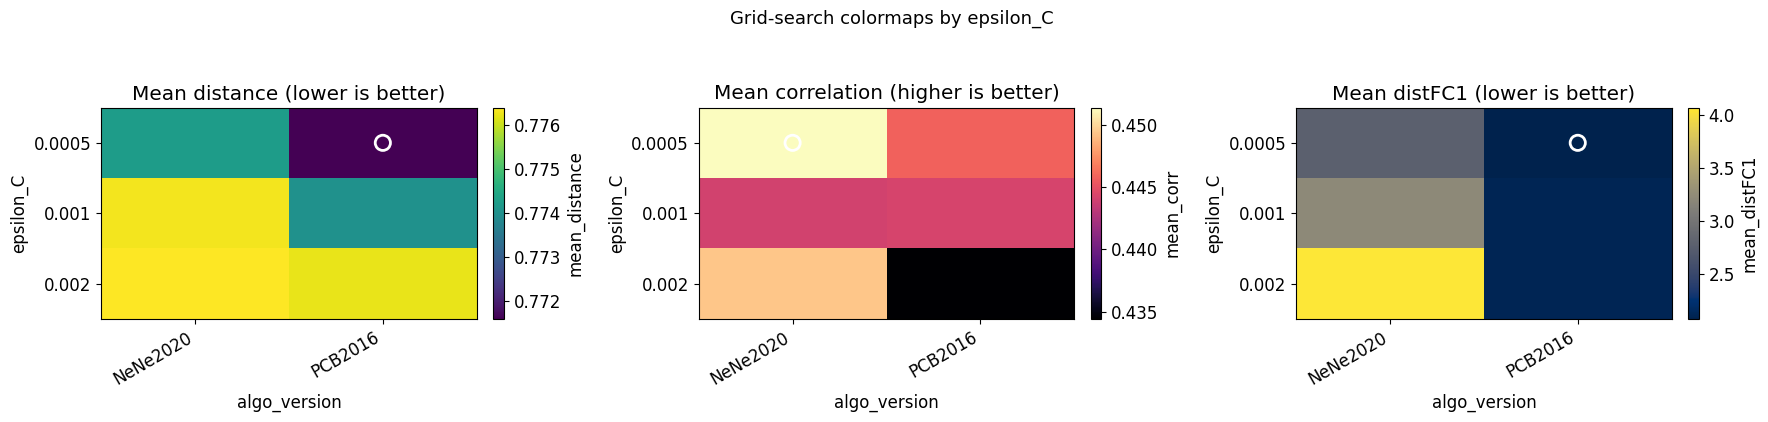

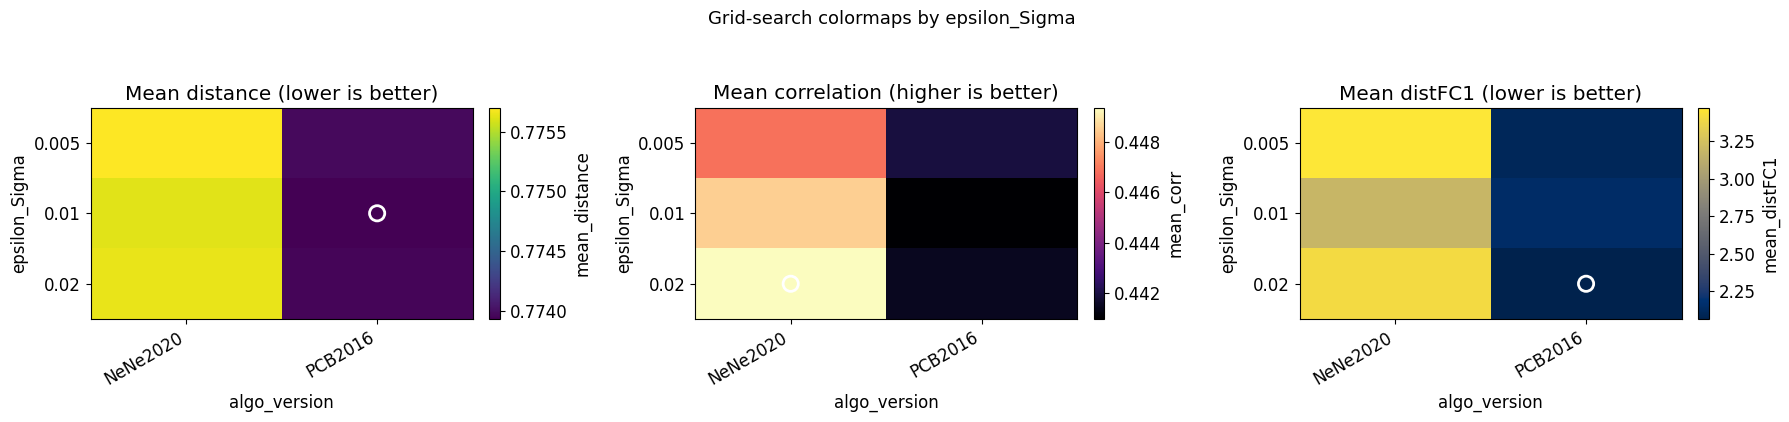

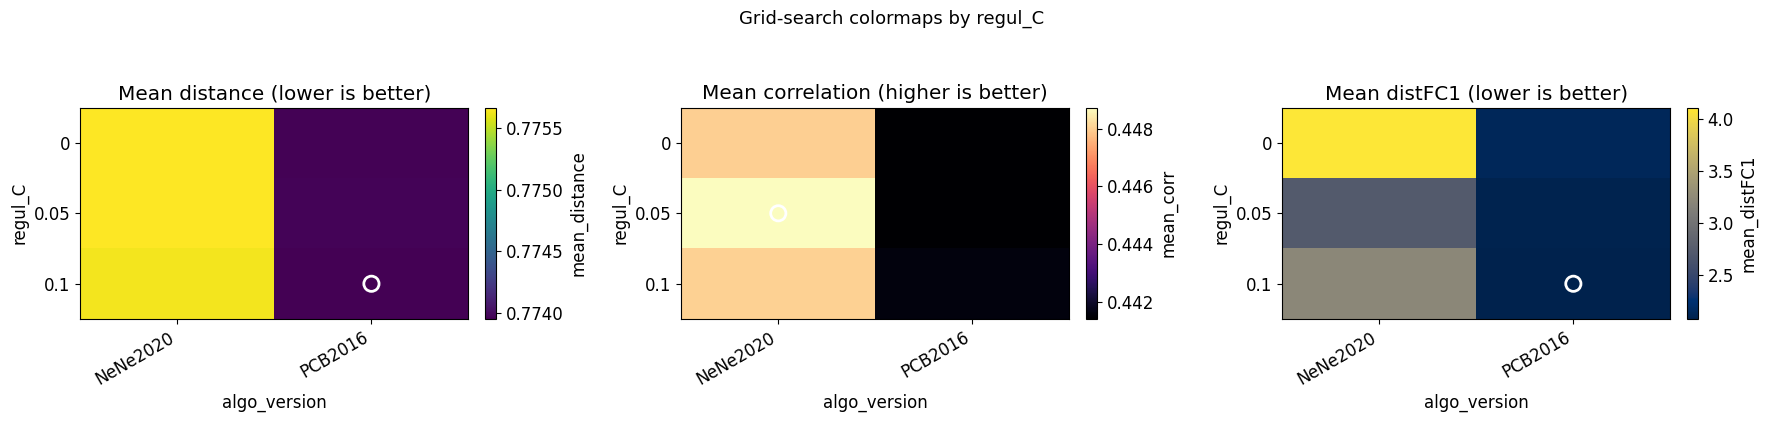

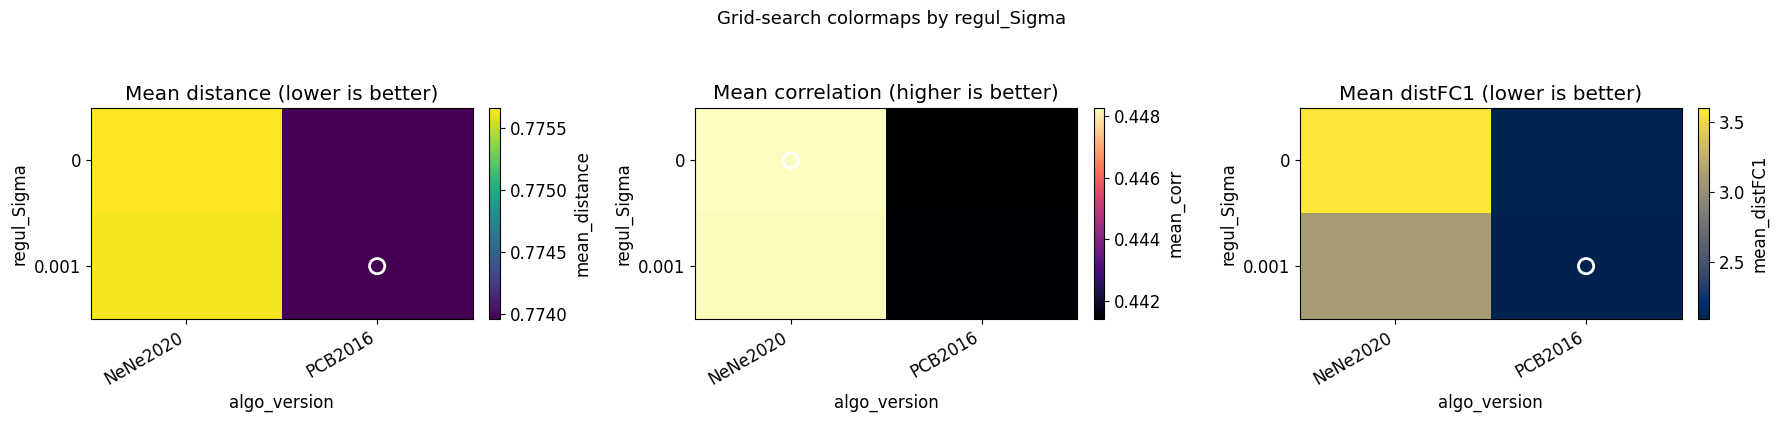

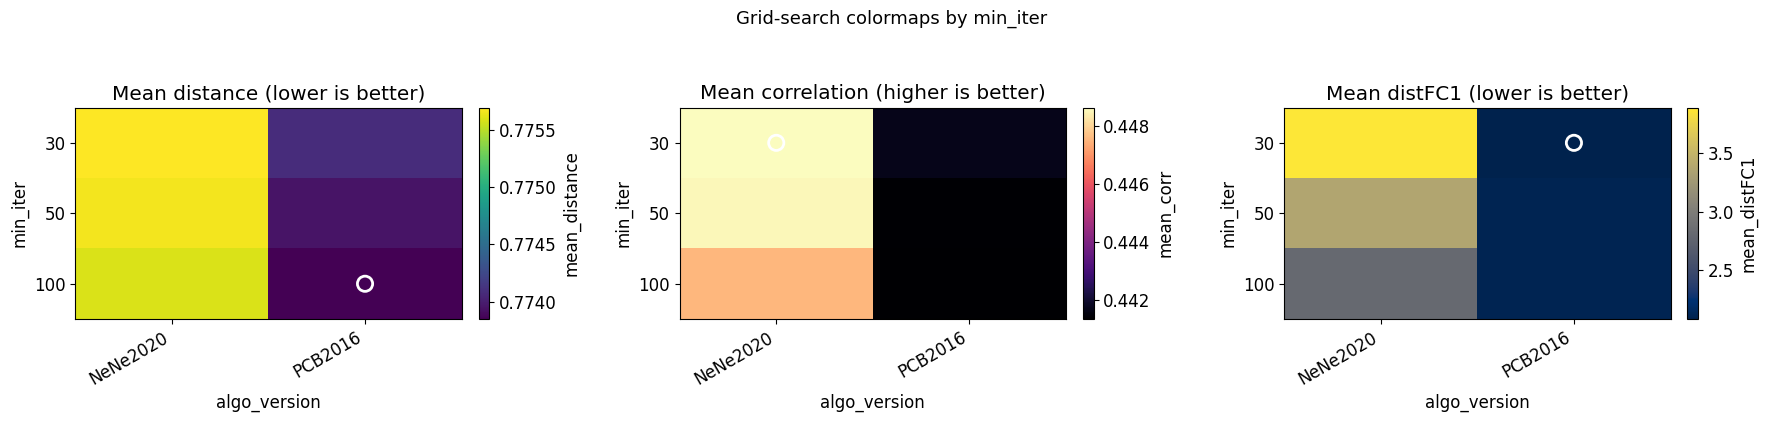

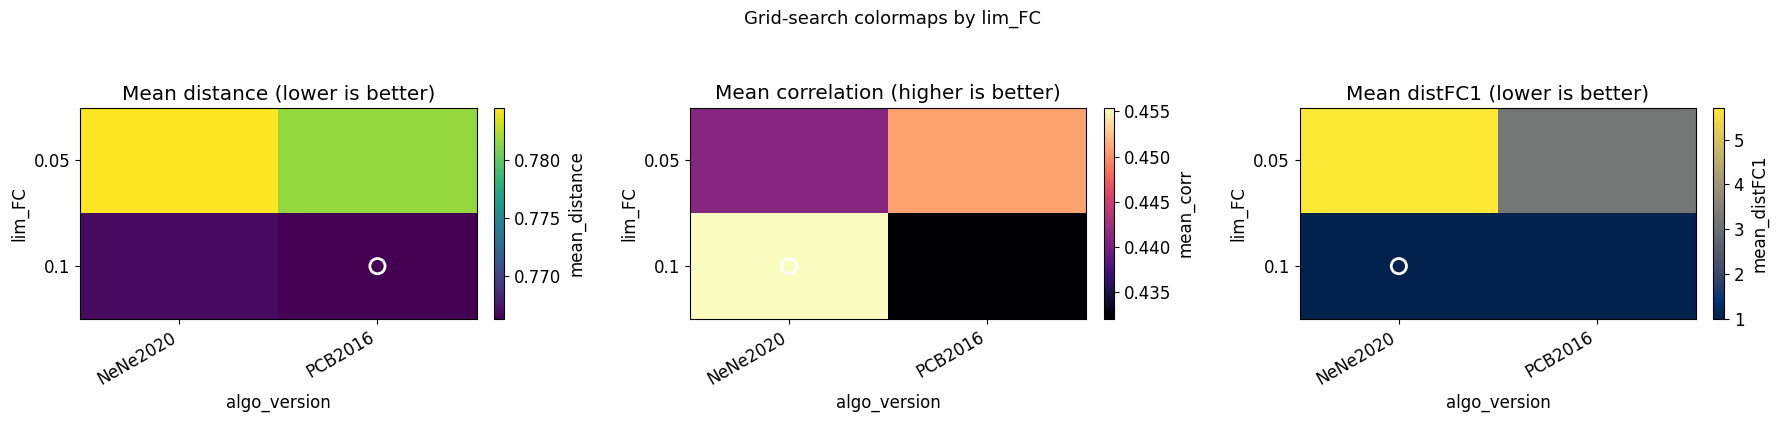

In [ ]:
# Colormap plots per parameter from grid-search results

#if "results" not in globals or results.empty:
 #   raise ValueError("No sweep results found. Run the grid-search cell first.")

params_to_plot = [
    "epsilon_C",
    "epsilon_Sigma",
    "regul_C",
    "regul_Sigma",
    "min_iter",
    "lim_FC",
]

metrics = [
    ("mean_distance", "Mean distance (lower is better)", "viridis", "min"),
    ("mean_corr", "Mean correlation (higher is better)", "magma", "max"),
    ("mean_distFC1", "Mean distFC1 (lower is better)", "cividis", "min"),
]

def _fmt(v):
    if isinstance(v, (int, np.integer)):
        return str(int(v))
    return f"{float(v):.3g}"

for p in params_to_plot:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    for ax, (metric, title, cmap, best_mode) in zip(axes, metrics):
        pt = results.pivot_table(
            index=p,
            columns="algo_version",
            values=metric,
            aggfunc="mean"
        ).sort_index()

        if pt.shape[0] == 0 or pt.shape[1] == 0:
            ax.set_axis_off()
            continue

        im = ax.imshow(pt.values, aspect="auto", cmap=cmap)

        ax.set_title(title)
        ax.set_xlabel("algo_version")
        ax.set_ylabel(p)
        ax.set_xticks(np.arange(len(pt.columns)))
        ax.set_xticklabels([str(c) for c in pt.columns], rotation=30, ha="right")
        ax.set_yticks(np.arange(len(pt.index)))
        ax.set_yticklabels([_fmt(v) for v in pt.index])

        # mark best cell on each heatmap
        vals = pt.values
        if best_mode == "min":
            iy, ix = np.unravel_index(np.nanargmin(vals), vals.shape)
        else:
            iy, ix = np.unravel_index(np.nanargmax(vals), vals.shape)
        ax.scatter(ix, iy, s=120, facecolors="none", edgecolors="white", linewidths=2)

        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.set_ylabel(metric, rotation=90)

    fig.suptitle(f"Grid-search colormaps by {p}", y=1.05, fontsize=13)
    plt.tight_layout()
    plt.show()